# 2-bit quantizer sample-size experiment

This notebook uses a pilot-based sample-size workflow: choose confidence and power, estimate the standard deviation with a pilot run, then calculate how many paired observations are needed.

The active algorithms are Leech Lattice Vector Quantization, uniform scalar 2-bit, QTIP bitshift K=2, and QuIP# E8P12. QTIP and QuIP# are included as additional algorithms in the comparison. The final analysis uses repeated-measures ANOVA first, followed by planned Bonferroni-corrected post-hoc paired comparisons.


In [67]:
from __future__ import annotations

import contextlib
import importlib.util
import io
import json
import math
import random
import re
import subprocess
import sys
import time
import types
from dataclasses import dataclass
from pathlib import Path

import numpy as np

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

try:
    import torch
    TORCH_AVAILABLE = True
    TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
except Exception as exc:
    torch = None
    TORCH_AVAILABLE = False
    TORCH_IMPORT_ERROR = exc
    TORCH_DEVICE = None

try:
    import pandas as pd
except Exception:
    pd = None

try:
    from huggingface_hub import hf_hub_download
    from safetensors import safe_open
    HF_WEIGHTS_AVAILABLE = True
except Exception as exc:
    hf_hub_download = None
    safe_open = None
    HF_WEIGHTS_AVAILABLE = False
    HF_WEIGHTS_IMPORT_ERROR = exc

import matplotlib.pyplot as plt


def seed_everything(seed: int):
    random.seed(int(seed))
    np.random.seed(int(seed))
    if TORCH_AVAILABLE:
        torch.manual_seed(int(seed))
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(int(seed))
        if hasattr(torch.backends, "cudnn"):
            torch.backends.cudnn.benchmark = False
            torch.backends.cudnn.deterministic = True


print(f"root: {ROOT}")
print(f"torch available: {TORCH_AVAILABLE}")
print(f"torch device: {TORCH_DEVICE}")
print(f"HF weight loading available: {HF_WEIGHTS_AVAILABLE}")


root: /home/diego/Documents/master/llm-quantization-benchmarks
torch available: True
torch device: cuda
HF weight loading available: True


In [68]:
# Experiment configuration.
SEED = 0
DIM = 24
TARGET_BITS_PER_DIM = 2.0

# Algorithms: Leech Lattice Vector Quantization, uniform scalar 2-bit, QTIP bitshift K=2, and QuIP# E8P12.
LEECH_MAX_SHELL = 13
LEECH_ANN_TOP_SHELLS = 0
QTIP_REPO = ROOT / "third_party" / "qtip"
AUTO_CLONE_QTIP = True
QTIP_GIT_URL = "https://github.com/Cornell-RelaxML/qtip.git"
QTIP_CONFIG = dict(L=8, K=int(TARGET_BITS_PER_DIM), V=1, tlut_bits=8, decode_mode="quantlut")
QUIP_SHARP_REPO = ROOT / "third_party" / "quip-sharp"
AUTO_CLONE_QUIP_SHARP = True
QUIP_SHARP_GIT_URL = "https://github.com/Cornell-RelaxML/quip-sharp.git"
QUIP_SHARP_CODEBOOK = "E8P12"

# Main input source: random 24D blocks from actual checkpoint tensors.
DATA_SOURCE = "llm_weight_blocks"
LLM_REPO_ID = "Qwen/Qwen3-0.6B"
LLM_WEIGHTS_FILENAME = "model.safetensors"
LLM_TENSOR_NAME_PATTERN = r"^model\.layers\.(\d+)\.mlp\.down_proj\.weight$"
LLM_SAMPLE_SEED = SEED + 2026
# block_rms keeps the real weight distribution shape while matching the current no-scale quantizer setup.
# Use "none" to quantize the raw checkpoint values directly.
LLM_WEIGHT_NORMALIZATION = "block_rms"

# No external/global scale in this experiment.
USE_SHARED_SCALE = False
SCALE_BITS = 0
SCALE_GRANULARITY = "none"
PER_VECTOR_SCALAR_BITS = 0

# Sample size calculation settings: alpha, power, SD, and minimum interesting effect.
# One run/block is one vector evaluated by every algorithm.
# Each run records MSE, SQNR, quantize time, and dequantize time from the same quantize/dequantize call.
PILOT_QUALITY_N = 30
PILOT_TIMING_REPEATS = 30
TIMING_WARMUP_REPEATS = 5
TIMING_RANDOMIZE_ORDER = True


ALPHA = 0.05
POWER = 0.80

TWO_SIDED = True
# Controls post-hoc Type-I error. "all_metrics" controls all metrics and method comparisons together.
# Use "per_metric" to control each metric family separately.
FWER_SCOPE = "all_metrics"
N_METRICS_FOR_FWER = 3
MHT_CORRECTION_METHOD = "bonferroni"  # "bonferroni" or "sidak"

# Power-analysis sample-size scenarios for the four-algorithm mean comparison.
ANOVA_EFFECT_SCENARIOS = ("two_levels_symmetric", "one_vs_rest")

# Minimum interesting effects. Adjust these to match the claim you want to make.
MIN_INTERESTING_SQNR_BITS_DIFF = 0.10
MIN_INTERESTING_QUANTIZE_SECONDS = 0.1
MIN_INTERESTING_DEQUANTIZE_SECONDS = 0.01

# CSV output. Each top-to-bottom notebook execution writes exactly two raw data files in this deterministic run directory.
# Re-running with the same SEED overwrites the same pilot/final CSVs, which keeps the experiment reproducible.
RESULTS_DIR = ROOT / "results" / "quantizer_sample_size_experiment"
RUN_ID = f"seed{SEED}_{DATA_SOURCE}"
RUN_DIR = RESULTS_DIR / RUN_ID


## Weight sampling


In [69]:
def make_rng(offset: int = 0):
    return np.random.default_rng(SEED + int(offset))


LLM_BLOCK_METADATA = []


def llm_weight_tensor_candidates(f) -> list[dict]:
    pattern = re.compile(LLM_TENSOR_NAME_PATTERN)
    candidates = []
    for name in f.keys():
        match = pattern.match(name)
        if not match:
            continue
        shape = tuple(f.get_tensor(name).shape)
        n_values = int(np.prod(shape))
        candidates.append({
            "tensor_name": name,
            "layer": int(match.group(1)),
            "shape": shape,
            "n_blocks": n_values // DIM,
        })
    candidates.sort(key=lambda item: item["layer"])
    if not candidates:
        raise ValueError(f"no tensors matched LLM_TENSOR_NAME_PATTERN={LLM_TENSOR_NAME_PATTERN!r}")
    return candidates


def sample_llm_weight_locations(candidates: list[dict], n_needed: int) -> list[dict]:
    block_counts = np.asarray([item["n_blocks"] for item in candidates], dtype=np.int64)
    total_blocks = int(block_counts.sum())
    if int(n_needed) > total_blocks:
        raise ValueError(f"requested {n_needed} blocks, but only {total_blocks} full 24D blocks are available")
    rng = np.random.default_rng(LLM_SAMPLE_SEED)
    global_indices = rng.choice(total_blocks, size=int(n_needed), replace=False)
    cumulative = np.cumsum(block_counts)
    locations = []
    for global_index in global_indices:
        tensor_pos = int(np.searchsorted(cumulative, int(global_index), side="right"))
        previous = int(cumulative[tensor_pos - 1]) if tensor_pos else 0
        block_index = int(global_index) - previous
        candidate = candidates[tensor_pos]
        locations.append({
            "tensor_name": candidate["tensor_name"],
            "layer": int(candidate["layer"]),
            "block_index": int(block_index),
            "flat_start": int(block_index * DIM),
        })
    return locations


def load_llm_weight_blocks(n_blocks: int, offset_blocks: int = 0) -> np.ndarray:
    if not HF_WEIGHTS_AVAILABLE:
        raise RuntimeError(f"Hugging Face weight loading is unavailable: {HF_WEIGHTS_IMPORT_ERROR}")
    if not TORCH_AVAILABLE:
        raise RuntimeError("torch is required to read safetensors weights")
    path = hf_hub_download(LLM_REPO_ID, filename=LLM_WEIGHTS_FILENAME)
    n_blocks = int(n_blocks)
    offset_blocks = int(offset_blocks)
    with safe_open(path, framework="pt", device="cpu") as f:
        candidates = llm_weight_tensor_candidates(f)
        locations = sample_llm_weight_locations(candidates, offset_blocks + n_blocks)[offset_blocks:offset_blocks + n_blocks]
        blocks = np.empty((n_blocks, DIM), dtype=np.float32)
        for tensor_name in sorted({loc["tensor_name"] for loc in locations}):
            tensor = f.get_tensor(tensor_name).flatten().to(torch.float32)
            for row_id, loc in enumerate(locations):
                if loc["tensor_name"] != tensor_name:
                    continue
                start = int(loc["flat_start"])
                blocks[row_id] = tensor[start:start + DIM].cpu().numpy().astype(np.float32)
    raw_rms = np.sqrt(np.mean(blocks.astype(np.float64) ** 2, axis=1))
    if LLM_WEIGHT_NORMALIZATION == "block_rms":
        blocks = blocks / np.maximum(raw_rms[:, None].astype(np.float32), 1e-12)
    elif LLM_WEIGHT_NORMALIZATION == "global_rms":
        rms = float(np.sqrt(np.mean(blocks.astype(np.float64) ** 2)))
        blocks = blocks / max(rms, 1e-12)
    elif LLM_WEIGHT_NORMALIZATION != "none":
        raise ValueError(f"unknown LLM_WEIGHT_NORMALIZATION: {LLM_WEIGHT_NORMALIZATION}")
    global LLM_BLOCK_METADATA
    LLM_BLOCK_METADATA = [
        {**loc, "normalization": LLM_WEIGHT_NORMALIZATION, "raw_rms": float(raw_rms[i])}
        for i, loc in enumerate(locations)
    ]
    return blocks.astype(np.float32)


def make_input_blocks(n_blocks: int, rng, offset_blocks: int = 0) -> np.ndarray:
    if DATA_SOURCE != "llm_weight_blocks":
        raise ValueError(f"this experiment is configured for LLM weight blocks, got: {DATA_SOURCE}")
    return load_llm_weight_blocks(int(n_blocks), offset_blocks=offset_blocks)


seed_everything(SEED)


In [70]:
@dataclass
class QuantizerReport:
    method: str
    rate_bits_per_dim: float
    mse: float
    rmse: float
    error_std: float
    squared_error_std: float
    sqnr_bits: float
    scale: float
    seconds: float
    quantize_seconds: float
    dequantize_seconds: float
    metadata: dict


def mse_to_sqnr_bits(mse: float) -> float:
    return float("inf") if mse == 0 else -0.5 * math.log2(mse)


def reconstruction_error_stats(x: np.ndarray, recon: np.ndarray) -> dict[str, float]:
    error = x - recon
    squared_error = error ** 2
    mse = float(np.mean(squared_error))
    return {
        "mse": mse,
        "rmse": float(math.sqrt(mse)),
        "error_std": float(np.std(error)),
        "squared_error_std": float(np.std(squared_error)),
    }


def synchronize_for_timing():
    if TORCH_AVAILABLE and torch.cuda.is_available():
        torch.cuda.synchronize()


def reports_table(reports):
    rows = [
        {
            "method": r.method,
            "rate_bpd": r.rate_bits_per_dim,
            "side_info_bpd": float(r.metadata.get("side_info_bpd", 0.0)),
            "effective_rate_bpd": r.rate_bits_per_dim + float(r.metadata.get("side_info_bpd", 0.0)),
            "target_delta_bpd": r.rate_bits_per_dim + float(r.metadata.get("side_info_bpd", 0.0)) - TARGET_BITS_PER_DIM,
            "mse": r.mse,
            "rmse": r.rmse,
            "error_std": r.error_std,
            "squared_error_std": r.squared_error_std,
            "sqnr_bits": r.sqnr_bits,
            "scale": r.scale,
            "seconds": r.seconds,
            "quantize_seconds": r.quantize_seconds,
            "dequantize_seconds": r.dequantize_seconds,
            "metadata": r.metadata,
        }
        for r in reports
    ]
    if pd is not None:
        return pd.DataFrame(rows).sort_values(["mse", "seconds"]).reset_index(drop=True)
    return rows


## Leech lattice vector quantizer

This wraps the local `leech_lattice_vector_quantizer` module. If CUDA is available, it uses the batched GPU implementation; otherwise it falls back to the CPU implementation. The current CPU implementation prints the winning codeword during quantization, so the wrapper suppresses that output for table runs.


In [71]:
class LeechNotebookQuantizer:
    def __init__(self, max_shell: int, ann_top_shells: int = 0):
        self.max_shell = max_shell
        self.ann_top_shells = int(ann_top_shells)
        self.backend = "cpu"
        self.device = "cpu"

        if TORCH_AVAILABLE and torch.cuda.is_available():
            try:
                from leech_lattice_vector_quantizer.leech_lattice_vector_quantizer_gpu import LeechLatticeVectorQuantizerGpu

                self.quantizer = LeechLatticeVectorQuantizerGpu(max_shell=max_shell, verbose=False, device="cuda")
                self.quantizer._quantize_cuda_metadata()["ann_top_shells"] = self.ann_top_shells
                # Trigger NVRTC compilation here so setup errors are reported before the benchmark loop.
                warm_x = torch.zeros((1, 24), dtype=torch.float32, device=self.quantizer.device)
                warm_idx = self.quantizer.quantize(warm_x)
                _ = self.quantizer.dequantize(warm_idx, check_bounds=False)
                torch.cuda.synchronize()
                self.backend = "gpu"
                self.device = str(self.quantizer.device)
            except Exception as exc:
                print(f"Leech GPU unavailable, falling back to CPU: {type(exc).__name__}: {exc}")
                from leech_lattice_vector_quantizer.leech_lattice_vector_quantizer import LeechLatticeVectorQuantizer

                self.quantizer = LeechLatticeVectorQuantizer(max_shell=max_shell, verbose=False)
        else:
            from leech_lattice_vector_quantizer.leech_lattice_vector_quantizer import LeechLatticeVectorQuantizer

            self.quantizer = LeechLatticeVectorQuantizer(max_shell=max_shell, verbose=False)
        self.rate = self.quantizer.shape_bits / 24.0

    def quantize_normalized(self, samples: np.ndarray) -> np.ndarray:
        return self.decode_normalized(self.encode_normalized(samples))

    def encode_normalized(self, samples: np.ndarray):
        if samples.shape[-1] != 24:
            raise ValueError("Leech quantizer expects 24-D rows")
        if self.backend == "gpu":
            x = torch.as_tensor(samples, dtype=torch.float32, device=self.quantizer.device)
            with torch.no_grad():
                return self.quantizer.quantize(x)

        indices = np.empty(samples.shape[:-1], dtype=np.int64)
        for i, row in enumerate(samples):
            with contextlib.redirect_stdout(io.StringIO()):
                indices[i] = self.quantizer.quantize(row)
        return indices

    def decode_normalized(self, indices) -> np.ndarray:
        if self.backend == "gpu":
            with torch.no_grad():
                recon = self.quantizer.dequantize(indices, check_bounds=False)
            return recon.detach().cpu().numpy().astype(np.float32)

        out = np.empty((*np.asarray(indices).shape, 24), dtype=np.float32)
        for i, idx in enumerate(np.asarray(indices).reshape(-1)):
            out.reshape(-1, 24)[i] = np.asarray(self.quantizer.dequantize(int(idx)), dtype=np.float32)
        return out


## QTIP bitshift quantizer

The QTIP repository imports compiled kernel bindings at package import time. For this notebook's codebook-only test, the loader below installs minimal stubs and imports `lib/codebook/bitshift.py` directly. Install `torch` first; the notebook can clone `Cornell-RelaxML/qtip` into `third_party/qtip` if missing.


In [72]:
def ensure_qtip_repo(repo_path: Path, auto_clone: bool = True) -> Path | None:
    if repo_path.exists():
        return repo_path
    if not auto_clone:
        return None
    repo_path.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(["git", "clone", "--depth", "1", QTIP_GIT_URL, str(repo_path)], check=True)
    return repo_path


def load_qtip_bitshift_module(qtip_repo: Path):
    if not TORCH_AVAILABLE:
        raise RuntimeError(f"torch is required for QTIP: {TORCH_IMPORT_ERROR}")

    sys.modules.setdefault("lib", types.ModuleType("lib"))

    codebook_stub = types.ModuleType("lib.codebook")
    codebook_stub.kdict = {}
    sys.modules["lib.codebook"] = codebook_stub

    sys.modules.setdefault("lib.utils", types.ModuleType("lib.utils"))

    kernel_check = types.ModuleType("lib.utils.kernel_check")
    kernel_check.has_kernel = lambda *args, **kwargs: False
    sys.modules["lib.utils.kernel_check"] = kernel_check

    kernel_decompress = types.ModuleType("lib.utils.kernel_decompress")

    def _decode_compressed_not_used(*args, **kwargs):
        raise RuntimeError("kernel decompression is not used in this codebook-only notebook test")

    kernel_decompress.decode_compressed = _decode_compressed_not_used
    sys.modules["lib.utils.kernel_decompress"] = kernel_decompress

    matmul_had = types.ModuleType("lib.utils.matmul_had")
    matmul_had.matmul_hadU_cuda = lambda *args, **kwargs: None
    matmul_had.matmul_hadUt_cuda = lambda *args, **kwargs: None
    sys.modules["lib.utils.matmul_had"] = matmul_had

    module_path = qtip_repo / "lib" / "codebook" / "bitshift.py"
    spec = importlib.util.spec_from_file_location("qtip_bitshift_notebook", module_path)
    module = importlib.util.module_from_spec(spec)
    if spec.loader is None:
        raise ImportError(module_path)

    # The codebook smoke test runs fine in eager mode. QTIP decorates one helper with
    # torch.compile, which requires a C++ compiler through Inductor even on CPU.
    # Temporarily disabling the decorator keeps this notebook portable.
    original_compile = torch.compile
    torch.compile = lambda fn=None, *args, **kwargs: (lambda f: f) if fn is None else fn
    try:
        spec.loader.exec_module(module)
    finally:
        torch.compile = original_compile
    return module


class QTIPNotebookQuantizer:
    def __init__(self, repo_path: Path, config: dict, device=None):
        module = load_qtip_bitshift_module(repo_path)
        self.config = dict(config)
        self.device = device if device is not None else torch.device("cpu")
        self.backend = "gpu" if self.device.type == "cuda" else "cpu"
        self.cb = module.bitshift_codebook(**self.config).to(self.device)
        self.cb.fakeinf = self.cb.fakeinf.to(self.device)
        self.rate = float(self.config["K"])

    def quantize_normalized(self, samples: np.ndarray) -> np.ndarray:
        return self.decode_normalized(self.encode_normalized(samples))

    def encode_normalized(self, samples: np.ndarray):
        x = torch.as_tensor(samples, dtype=torch.float32, device=self.device)
        with torch.no_grad():
            x_t = x.T.contiguous().to(torch.float16)
            T = x_t.shape[0]
            roll_x = torch.roll(x_t, T // (2 * self.cb.V) * self.cb.V, 0)
            states = self.cb.quantize_seq(roll_x, overlap=None)
            overlap = states[T // (2 * self.cb.V)] >> self.cb.K * self.cb.V
            states = self.cb.quantize_seq(x_t, overlap=overlap)
            states = states.T.contiguous().to(self.device)
        self.last_states = states
        return states

    def decode_normalized(self, states) -> np.ndarray:
        states = states.to(self.device) if torch.is_tensor(states) else torch.as_tensor(states, device=self.device)
        with torch.no_grad():
            states_t = states.T.contiguous()
            batch = states.shape[0]
            dim = states.shape[1] * self.cb.V
            recon = self.cb.recons(states_t).transpose(0, 1).reshape(dim, batch).T.contiguous()
        self.last_states = states
        return recon.detach().cpu().numpy().astype(np.float32)


def ensure_quip_sharp_repo(repo_path: Path, auto_clone: bool = True) -> Path | None:
    if repo_path.exists():
        return repo_path
    if not auto_clone:
        return None
    repo_path.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(["git", "clone", "--depth", "1", QUIP_SHARP_GIT_URL, str(repo_path)], check=True)
    return repo_path


def load_quip_codebook_class(repo_root: Path, name: str):
    from leech_lattice_vector_quantizer.gaussian_baseline_quantizers import load_quip_codebook_class as load_class

    return load_class(repo_root, name)


class QuipSharpE8NotebookQuantizer:
    def __init__(self, repo_path: Path, codebook_name: str, device=None):
        if repo_path is None:
            raise FileNotFoundError("missing third_party/quip-sharp")
        Codebook = load_quip_codebook_class(ROOT, codebook_name)
        self.codebook_name = codebook_name
        self.device = device if device is not None else torch.device("cpu")
        self.backend = "gpu" if self.device.type == "cuda" else "cpu"
        self.codebook = Codebook(inference=False).to(self.device)
        self.rate = float(TARGET_BITS_PER_DIM)

    def quantize_normalized(self, samples: np.ndarray) -> np.ndarray:
        return self.decode_normalized(self.encode_normalized(samples))

    def encode_normalized(self, samples: np.ndarray):
        if samples.shape[-1] % 8 != 0:
            raise ValueError("QuIP# E8P12 expects rows with dimension divisible by 8")
        blocks = torch.as_tensor(samples.reshape(-1, 8), dtype=torch.float32, device=self.device)
        with torch.no_grad():
            _, indices = self.codebook.quantize(blocks, return_idx=True)
        return indices.reshape(samples.shape[0], samples.shape[1] // 8).contiguous()

    def decode_normalized(self, indices) -> np.ndarray:
        indices = indices.to(self.device) if torch.is_tensor(indices) else torch.as_tensor(indices, device=self.device)
        with torch.no_grad():
            recon = self.codebook.grid[indices.reshape(-1).long()]
        return recon.reshape(indices.shape[0], indices.shape[1] * 8).detach().cpu().numpy().astype(np.float32)


## Uniform scalar quantizer

A clipped per-coordinate uniform scalar quantizer is included as a simple exact-rate baseline.


In [73]:
class UniformScalarNotebookQuantizer:
    def __init__(self, bits: int, device=None):
        if bits < 1:
            raise ValueError("bits must be positive")
        self.bits = int(bits)
        self.levels = 1 << self.bits
        self.qmin = -(self.levels // 2)
        self.qmax = self.levels // 2 - 1
        self.rate = float(self.bits)
        self.device = device if TORCH_AVAILABLE and device is not None else None
        self.backend = "gpu" if self.device is not None and self.device.type == "cuda" else "cpu"

    def quantize_normalized(self, samples: np.ndarray) -> np.ndarray:
        return self.decode_normalized(self.encode_normalized(samples))

    def encode_normalized(self, samples: np.ndarray):
        if self.device is None:
            return np.clip(np.round(samples), self.qmin, self.qmax).astype(np.int16)
        x = torch.as_tensor(samples, dtype=torch.float32, device=self.device)
        with torch.no_grad():
            return torch.clamp(torch.round(x), self.qmin, self.qmax).to(torch.int16)

    def decode_normalized(self, codes) -> np.ndarray:
        if torch is not None and torch.is_tensor(codes):
            return codes.to(torch.float32).detach().cpu().numpy()
        return np.asarray(codes, dtype=np.float32)


## Pilot experiment and analysis setup

After the pilot diagnostics and plots, the notebook calculates three global sample sizes:

- Quality: number of observations per algorithm needed for SQNR bits.
- Quantize time: number of observations per algorithm needed for quantize time.
- Dequantize time: number of observations per algorithm needed for dequantize time.

The parametric sample-size block defines mean-difference scenarios, estimates the within-algorithm variance from the pilot data, calculates global F-test power with a noncentral F distribution, and uses the largest required sample size across metrics and scenarios. Post-hoc pairwise calculations are kept as a separate secondary check.


## Sample-size helper functions


In [74]:
from itertools import combinations

from scipy import stats


def normal_quantile(p: float) -> float:
    return float(stats.norm.ppf(float(p)))


def pilot_sample_size_for_sd(confidence: float = 0.95, relative_error: float = 0.25) -> int:
    # Pilot-study approximation: n_pilot ~= 2 * (z_{alpha_n/2} / e_n)^2.
    alpha_n = 1.0 - float(confidence)
    z = normal_quantile(1.0 - alpha_n / 2.0)
    return int(math.ceil(2.0 * (z / float(relative_error)) ** 2))


def paired_t_power(n: int, sd_diff: float, delta: float, alpha: float, two_sided: bool = True) -> float:
    if n < 2 or sd_diff <= 0.0:
        return 0.0
    df = int(n) - 1
    ncp = math.sqrt(float(n)) * float(delta) / float(sd_diff)
    if two_sided:
        tcrit = float(stats.t.ppf(1.0 - alpha / 2.0, df))
        value = float(stats.nct.sf(tcrit, df, ncp) + stats.nct.cdf(-tcrit, df, ncp))
    else:
        tcrit = float(stats.t.ppf(1.0 - alpha, df))
        value = float(stats.nct.sf(tcrit, df, ncp))
    if not math.isfinite(value):
        return 1.0 if ncp > 0.0 else 0.0
    return min(1.0, max(0.0, value))


def paired_sample_size_t(sd_diff: float, delta: float, alpha: float, power: float, two_sided: bool = True) -> int:
    if delta <= 0.0:
        raise ValueError("delta must be positive")
    if sd_diff <= 0.0:
        return 2

    lo = 2
    hi = 2
    while paired_t_power(hi, sd_diff, delta, alpha, two_sided) < power:
        hi *= 2
        if hi > 10_000_000:
            raise RuntimeError("sample-size search exceeded 10,000,000 observations")

    while lo < hi:
        mid = (lo + hi) // 2
        if paired_t_power(mid, sd_diff, delta, alpha, two_sided) >= power:
            hi = mid
        else:
            lo = mid + 1
    return int(lo)


## Experiment metric helpers and runner


In [75]:
def per_vector_mse(x: np.ndarray, recon: np.ndarray) -> np.ndarray:
    return np.mean((x.astype(np.float64, copy=False) - recon.astype(np.float64, copy=False)) ** 2, axis=1)


def per_vector_sqnr_bits(x: np.ndarray, recon: np.ndarray, eps: float = 1e-30) -> np.ndarray:
    x64 = x.astype(np.float64, copy=False)
    recon64 = recon.astype(np.float64, copy=False)
    signal_power = np.mean(x64 ** 2, axis=1)
    noise_power = np.mean((x64 - recon64) ** 2, axis=1)
    ratio = np.maximum(signal_power, eps) / np.maximum(noise_power, eps)
    return 0.5 * np.log2(ratio)


## Quantizer registry


In [76]:
def make_quantizer_items():
    quantizer_device = TORCH_DEVICE if TORCH_AVAILABLE else None
    items = []

    leech = LeechNotebookQuantizer(LEECH_MAX_SHELL, ann_top_shells=LEECH_ANN_TOP_SHELLS)
    leech_mode = "exact" if leech.ann_top_shells <= 0 else f"top{leech.ann_top_shells}"
    items.append({
        "method": f"Leech Lattice Vector Quantization ({leech.backend})",
        "rate": leech.rate,
        "encode": leech.encode_normalized,
        "decode": leech.decode_normalized,
        "metadata": {
            "target_bpd": TARGET_BITS_PER_DIM,
            "backend": leech.backend,
            "device": leech.device,
            "ann_top_shells": leech.ann_top_shells,
            "approximate": bool(leech.ann_top_shells > 0),
            "total_count": int(leech.quantizer.total_count),
            "shape_bits": int(leech.quantizer.shape_bits),
        },
    })

    uniform = UniformScalarNotebookQuantizer(bits=int(TARGET_BITS_PER_DIM), device=quantizer_device)
    items.append({
        "method": f"Uniform scalar 2-bit ({uniform.backend})",
        "rate": uniform.rate,
        "encode": uniform.encode_normalized,
        "decode": uniform.decode_normalized,
        "metadata": {
            "target_bpd": TARGET_BITS_PER_DIM,
            "bits": uniform.bits,
            "levels": uniform.levels,
            "backend": uniform.backend,
            "device": str(uniform.device),
        },
    })

    qtip_status = "not run"
    quip_sharp_status = "not run"
    if TORCH_AVAILABLE:
        try:
            qtip_repo = ensure_qtip_repo(QTIP_REPO, auto_clone=AUTO_CLONE_QTIP)
            qtip = QTIPNotebookQuantizer(qtip_repo, QTIP_CONFIG, device=quantizer_device)
            items.append({
                "method": f"QTIP bitshift ({qtip.backend})",
                "rate": qtip.rate,
                "encode": qtip.encode_normalized,
                "decode": qtip.decode_normalized,
                "metadata": {
                    "target_bpd": TARGET_BITS_PER_DIM,
                    "backend": qtip.backend,
                    "device": str(qtip.device),
                    **QTIP_CONFIG,
                },
            })
            qtip_status = f"run ({qtip.backend}, {qtip.device})"
        except Exception as exc:
            qtip_status = f"skipped: {type(exc).__name__}: {exc}"

        try:
            quip_sharp_repo = ensure_quip_sharp_repo(QUIP_SHARP_REPO, auto_clone=AUTO_CLONE_QUIP_SHARP)
            quip_sharp = QuipSharpE8NotebookQuantizer(quip_sharp_repo, QUIP_SHARP_CODEBOOK, device=quantizer_device)
            items.append({
                "method": f"QuIP# {QUIP_SHARP_CODEBOOK} ({quip_sharp.backend})",
                "rate": quip_sharp.rate,
                "encode": quip_sharp.encode_normalized,
                "decode": quip_sharp.decode_normalized,
                "metadata": {
                    "target_bpd": TARGET_BITS_PER_DIM,
                    "backend": quip_sharp.backend,
                    "device": str(quip_sharp.device),
                    "codebook": quip_sharp.codebook_name,
                    "block_dim": 8,
                },
            })
            quip_sharp_status = f"run ({quip_sharp.backend}, {quip_sharp.device})"
        except Exception as exc:
            quip_sharp_status = f"skipped: {type(exc).__name__}: {exc}"
    else:
        qtip_status = f"skipped: torch unavailable: {TORCH_IMPORT_ERROR}"
        quip_sharp_status = f"skipped: torch unavailable: {TORCH_IMPORT_ERROR}"

    optional_status = f"QTIP {qtip_status}; QuIP# {quip_sharp_status}"
    return items, optional_status


## Experiment runner


In [77]:
def timed_call(fn, *args):
    synchronize_for_timing()
    start = time.perf_counter()
    result = fn(*args)
    synchronize_for_timing()
    return result, time.perf_counter() - start


## Run one experiment phase


In [78]:
def run_combined_experiment(
    items: list[dict],
    x: np.ndarray,
    *,
    phase: str,
    n_runs: int,
    warmup: int = 5,
    order_seed: int | None = None,
) -> tuple[Path, dict[str, np.ndarray], dict[str, np.ndarray], dict[str, np.ndarray], list[QuantizerReport]]:
    order_rng = np.random.default_rng(SEED if order_seed is None else int(order_seed))
    n_runs = int(n_runs)
    if x.shape[0] < n_runs:
        raise ValueError(f"x has {x.shape[0]} rows, but n_runs={n_runs}")

    rows = []
    quality_mse = {item["method"]: [] for item in items}
    quality_sqnr = {item["method"]: [] for item in items}
    quantize_times = {item["method"]: [] for item in items}
    dequantize_times = {item["method"]: [] for item in items}

    warm_x = x[:1]
    for item in items:
        for _ in range(warmup):
            codes = item["encode"](warm_x)
            _ = item["decode"](codes)
    synchronize_for_timing()

    for run_id in range(n_runs):
        x_run = x[run_id : run_id + 1]
        source = LLM_BLOCK_METADATA[run_id] if run_id < len(LLM_BLOCK_METADATA) else {}
        order = list(range(len(items)))
        if TIMING_RANDOMIZE_ORDER:
            order_rng.shuffle(order)

        for idx in order:
            item = items[idx]
            method = item["method"]
            codes, quantize_seconds = timed_call(item["encode"], x_run)
            recon, dequantize_seconds = timed_call(item["decode"], codes)
            mse_value = float(per_vector_mse(x_run, recon)[0])
            sqnr_value = float(per_vector_sqnr_bits(x_run, recon)[0])

            quality_mse[method].append(mse_value)
            quality_sqnr[method].append(sqnr_value)
            quantize_times[method].append(float(quantize_seconds))
            dequantize_times[method].append(float(dequantize_seconds))

            rows.append({
                "run_id": RUN_ID,
                "phase": phase,
                "block_id": int(run_id),
                "sample_id": int(run_id),
                "weight_tensor": source.get("tensor_name", ""),
                "weight_layer": source.get("layer", ""),
                "weight_block_index": source.get("block_index", ""),
                "weight_flat_start": source.get("flat_start", ""),
                "weight_raw_rms": source.get("raw_rms", ""),
                "weight_normalization": source.get("normalization", ""),
                "method": method,
                "mse": mse_value,
                "sqnr_bits": sqnr_value,
                "quantize_seconds": float(quantize_seconds),
                "dequantize_seconds": float(dequantize_seconds),
                "original_vector": json.dumps(x_run.reshape(-1).astype(float).tolist(), separators=(",", ":")),
                "dequantized_vector": json.dumps(np.asarray(recon).reshape(-1).astype(float).tolist(), separators=(",", ":")),
                "batch_n": 1,
                "dim": int(x.shape[1]),
                "seed": int(SEED),
            })

    reports = []
    for item in items:
        method = item["method"]
        mse_values = np.asarray(quality_mse[method], dtype=np.float64)
        sqnr_values = np.asarray(quality_sqnr[method], dtype=np.float64)
        quantize_values = np.asarray(quantize_times[method], dtype=np.float64)
        dequantize_values = np.asarray(dequantize_times[method], dtype=np.float64)
        mse = float(np.mean(mse_values))
        reports.append(QuantizerReport(
            method=method,
            rate_bits_per_dim=float(item["rate"]),
            mse=mse,
            rmse=float(math.sqrt(mse)),
            error_std=float("nan"),
            squared_error_std=float(np.std(mse_values, ddof=1)) if len(mse_values) > 1 else 0.0,
            sqnr_bits=float(np.mean(sqnr_values)),
            scale=1.0,
            seconds=float(np.mean(quantize_values + dequantize_values)),
            quantize_seconds=float(np.mean(quantize_values)),
            dequantize_seconds=float(np.mean(dequantize_values)),
            metadata={
                "side_info_bpd": 0.0,
                "scale_mode": "none",
                "shared_scale_bits": 0,
                "shared_scale_granularity": "none",
                **item["metadata"],
            },
        ))

    RUN_DIR.mkdir(parents=True, exist_ok=True)
    csv_path = RUN_DIR / f"{phase}_experiment.csv"
    pd.DataFrame(rows).to_csv(csv_path, index=False)
    return (
        csv_path,
        {name: np.asarray(values, dtype=np.float64) for name, values in quality_sqnr.items()},
        {name: np.asarray(values, dtype=np.float64) for name, values in quantize_times.items()},
        {name: np.asarray(values, dtype=np.float64) for name, values in dequantize_times.items()},
        reports,
    )


## CSV loading and multiple-comparison setup


In [79]:
def load_metric_samples_from_experiment_csv(csv_path: Path, metric: str) -> dict[str, np.ndarray]:
    df = pd.read_csv(csv_path)
    if metric not in {"mse", "sqnr_bits", "quantize_seconds", "dequantize_seconds"}:
        raise ValueError(f"unknown metric: {metric}")

    samples = {}
    for method, group in df.sort_values("block_id").groupby("method", sort=False):
        samples[method] = group[metric].to_numpy(dtype=np.float64)
    return samples




def adjusted_alpha_for_comparisons(alpha_family: float, n_comparisons: int, method: str = MHT_CORRECTION_METHOD) -> float:
    if n_comparisons <= 1:
        return float(alpha_family)
    method = str(method).lower()
    if method == "bonferroni":
        return float(alpha_family) / float(n_comparisons)
    if method == "sidak":
        return 1.0 - (1.0 - float(alpha_family)) ** (1.0 / float(n_comparisons))
    raise ValueError(f"unknown MHT correction method: {method}")


def pairwise_alpha_for_scope(n_methods: int, alpha: float) -> tuple[float, int]:
    n_comparisons = math.comb(n_methods, 2) if n_methods >= 2 else 0
    if n_comparisons == 0:
        return float(alpha), 1
    metric_families = int(N_METRICS_FOR_FWER) if FWER_SCOPE == "all_metrics" else 1
    total_planned_comparisons = n_comparisons * metric_families
    return adjusted_alpha_for_comparisons(alpha, total_planned_comparisons), total_planned_comparisons


def planned_comparisons_table(method_names: list[str], metrics: list[str], alpha_family: float = ALPHA) -> pd.DataFrame:
    n_pairwise = math.comb(len(method_names), 2) if len(method_names) >= 2 else 0
    metric_families = len(metrics) if FWER_SCOPE == "all_metrics" else 1
    total_planned_comparisons = n_pairwise * metric_families
    alpha_adjusted = adjusted_alpha_for_comparisons(alpha_family, total_planned_comparisons)
    rows = []
    for metric in metrics:
        for a, b in combinations(method_names, 2):
            rows.append({
                "metric": metric,
                "comparison": f"{a} vs {b}",
                "family_alpha": float(alpha_family),
                "alpha_adjustment_method": MHT_CORRECTION_METHOD,
                "fwer_scope": FWER_SCOPE,
                "n_pairwise_algorithm_comparisons": int(n_pairwise),
                "n_metric_families_in_correction": int(metric_families),
                "total_planned_comparisons": int(total_planned_comparisons),
                "adjusted_alpha": float(alpha_adjusted),
            })
    return pd.DataFrame(rows)


## ANOVA sample-size helpers


In [80]:
def sample_matrix(samples_by_method: dict[str, np.ndarray]) -> tuple[list[str], np.ndarray]:
    names = list(samples_by_method)
    values = [np.asarray(samples_by_method[name], dtype=np.float64) for name in names]
    if not values:
        raise ValueError("samples_by_method cannot be empty")
    first_shape = values[0].shape
    if any(value.shape != first_shape for value in values):
        raise ValueError("all paired sample arrays must have the same shape")
    return names, np.column_stack(values)



def anova_tau_vector(n_groups: int, delta: float, scenario: str) -> np.ndarray:
    n_groups = int(n_groups)
    delta = float(delta)
    if n_groups < 2:
        raise ValueError("ANOVA needs at least two groups")
    scenario = str(scenario)
    if scenario == "two_levels_symmetric":
        tau = np.zeros(n_groups, dtype=np.float64)
        tau[0] = -delta / 2.0
        tau[1] = delta / 2.0
        return tau
    if scenario == "one_vs_rest":
        tau = np.full(n_groups, delta / float(n_groups), dtype=np.float64)
        tau[0] = -delta * float(n_groups - 1) / float(n_groups)
        return tau
    raise ValueError(f"unknown ANOVA effect scenario: {scenario}")


def one_way_anova_within_variance(samples_by_method: dict[str, np.ndarray]) -> float:
    _, y = sample_matrix(samples_by_method)
    n_blocks, n_groups = y.shape
    if n_blocks < 2:
        return float("nan")
    group_means = np.mean(y, axis=0, keepdims=True)
    residuals = y - group_means
    ss_within = float(np.sum(residuals ** 2))
    df_within = int(n_groups * (n_blocks - 1))
    return ss_within / float(df_within) if df_within > 0 else float("nan")


## ANOVA power search


In [81]:
def anova_global_power(n_per_group: int, n_groups: int, sigma: float, delta: float, alpha: float, scenario: str) -> float:
    n_per_group = int(n_per_group)
    n_groups = int(n_groups)
    sigma = float(sigma)
    if n_per_group < 2 or n_groups < 2 or sigma <= 0.0:
        return 0.0
    tau = anova_tau_vector(n_groups, delta, scenario)
    df1 = n_groups - 1
    df2 = n_groups * (n_per_group - 1)
    noncentrality = float(n_per_group) * float(np.sum(tau ** 2)) / float(sigma ** 2)
    fcrit = float(stats.f.ppf(1.0 - float(alpha), df1, df2))
    power_value = float(stats.ncf.sf(fcrit, df1, df2, noncentrality))
    if not math.isfinite(power_value):
        return 0.0
    return min(1.0, max(0.0, power_value))


def anova_global_sample_size(n_groups: int, sigma: float, delta: float, alpha: float, power: float, scenario: str) -> int:
    if delta <= 0.0:
        raise ValueError("delta must be positive")
    if sigma <= 0.0:
        return 2
    lo = 2
    hi = 2
    while anova_global_power(hi, n_groups, sigma, delta, alpha, scenario) < power:
        hi *= 2
        if hi > 10_000_000:
            raise RuntimeError("ANOVA sample-size search exceeded 10,000,000 observations per group")
    while lo < hi:
        mid = (lo + hi) // 2
        if anova_global_power(mid, n_groups, sigma, delta, alpha, scenario) >= power:
            hi = mid
        else:
            lo = mid + 1
    return int(lo)


## ANOVA sample-size tables


In [82]:
def anova_sample_size_table_from_samples(
    samples_by_method: dict[str, np.ndarray],
    alpha: float,
    power: float,
    delta: float,
    metric: str,
    sample_unit: str,
    scenarios=ANOVA_EFFECT_SCENARIOS,
) -> pd.DataFrame:
    names, y = sample_matrix(samples_by_method)
    n_groups = len(names)
    within_variance = one_way_anova_within_variance(samples_by_method)
    sigma = math.sqrt(within_variance) if math.isfinite(within_variance) and within_variance >= 0.0 else float("nan")
    rows = []
    for scenario in scenarios:
        tau = anova_tau_vector(n_groups, delta, scenario)
        required_n = anova_global_sample_size(n_groups, sigma, delta, alpha, power, scenario)
        rows.append({
            "metric": metric,
            "sample_unit": sample_unit,
            "test": "one_way_anova_global_f_test",
            "scenario": scenario,
            "n_algorithms": int(n_groups),
            "pilot_samples_per_algorithm": int(y.shape[0]),
            "minimum_interesting_difference": float(delta),
            "family_alpha": float(alpha),
            "power": float(power),
            "pilot_within_variance": float(within_variance),
            "pilot_within_sd": float(sigma),
            "tau_vector": json.dumps(tau.astype(float).tolist(), separators=(",", ":")),
            "sum_tau_squared": float(np.sum(tau ** 2)),
            "between_variance_tau": float(np.var(tau, ddof=1)),
            "required_n_per_algorithm": int(required_n),
            "achieved_power_at_required_n": anova_global_power(required_n, n_groups, sigma, delta, alpha, scenario),
        })
    return pd.DataFrame(rows).sort_values("required_n_per_algorithm", ascending=False).reset_index(drop=True)


def required_anova_n_from_table(table: pd.DataFrame) -> int:
    if len(table) == 0:
        raise ValueError("empty ANOVA sample-size table")
    return int(table["required_n_per_algorithm"].max())


def add_anova_planned_power(table: pd.DataFrame, planned_n: int) -> pd.DataFrame:
    out = table.copy()
    out["planned_n_per_algorithm"] = int(planned_n)
    out["achieved_power_at_planned_n"] = [
        anova_global_power(
            int(planned_n),
            int(row.n_algorithms),
            float(row.pilot_within_sd),
            float(row.minimum_interesting_difference),
            float(row.family_alpha),
            str(row.scenario),
        )
        for row in out.itertuples(index=False)
    ]
    out["underpowered_at_planned_n"] = out["achieved_power_at_planned_n"] < out["power"]
    return out


## Secondary pairwise sample-size helpers


In [83]:
def sample_size_table_from_samples(samples_by_method: dict[str, np.ndarray], alpha: float, power: float, delta: float, metric: str, sample_unit: str):
    names = list(samples_by_method)
    n_comparisons = math.comb(len(names), 2) if len(names) >= 2 else 0
    alpha_pair, total_planned_comparisons = pairwise_alpha_for_scope(len(names), alpha)
    rows = []
    for a, b in combinations(names, 2):
        a_values = np.asarray(samples_by_method[a], dtype=np.float64)
        b_values = np.asarray(samples_by_method[b], dtype=np.float64)
        if a_values.shape != b_values.shape:
            raise ValueError(f"paired samples for {a} and {b} must have the same shape")
        diff = a_values - b_values
        sd_diff = float(np.std(diff, ddof=1))
        mean_diff = float(np.mean(diff))
        required_n = paired_sample_size_t(sd_diff, delta, alpha_pair, power, TWO_SIDED)
        rows.append({
            "metric": metric,
            "sample_unit": sample_unit,
            "comparison": f"{a} vs {b}",
            "pilot_mean_diff": mean_diff,
            "pilot_sd_diff": sd_diff,
            "minimum_interesting_difference": float(delta),
            "delta": float(delta),
            "family_alpha": float(alpha),
            "alpha_adjustment_method": MHT_CORRECTION_METHOD,
            "adjusted_alpha": float(alpha_pair),
            "alpha_pair": float(alpha_pair),
            "fwer_scope": FWER_SCOPE,
            "total_planned_comparisons": int(total_planned_comparisons),
            "power": float(power),
            "required_n": required_n,
            "achieved_power_at_required_n": paired_t_power(required_n, sd_diff, delta, alpha_pair, TWO_SIDED),
        })
    if pd is not None:
        return pd.DataFrame(rows).sort_values("required_n", ascending=False).reset_index(drop=True)
    return rows


def required_n_from_table(table) -> int:
    if pd is not None and hasattr(table, "__len__") and len(table) > 0:
        return int(table["required_n"].max())
    return max(row["required_n"] for row in table)


def add_planned_power(table, planned_n: int):
    if pd is None:
        rows = []
        for row in table:
            row = dict(row)
            planned_power = paired_t_power(
                int(planned_n),
                float(row["pilot_sd_diff"]),
                float(row["delta"]),
                float(row["alpha_pair"]),
                TWO_SIDED,
            )
            row["planned_n"] = int(planned_n)
            row["achieved_power_at_planned_n"] = planned_power
            row["underpowered_at_planned_n"] = bool(planned_power < float(row["power"]))
            rows.append(row)
        return rows

    out = table.copy()
    out["planned_n"] = int(planned_n)
    out["achieved_power_at_planned_n"] = [
        paired_t_power(
            int(planned_n),
            float(row.pilot_sd_diff),
            float(row.delta),
            float(row.alpha_pair),
            TWO_SIDED,
        )
        for row in out.itertuples(index=False)
    ]
    out["underpowered_at_planned_n"] = out["achieved_power_at_planned_n"] < out["power"]
    return out


## Descriptive statistics and plots


In [84]:
def metric_summary_from_values(values: np.ndarray, confidence: float = 0.95) -> dict:
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]
    n = int(values.size)
    if n == 0:
        return {
            "n": 0,
            "mean": float("nan"),
            "std_dev": float("nan"),
            "variance": float("nan"),
            "std_error": float("nan"),
            "coefficient_of_variation": float("nan"),
            "ci_level": confidence,
            "ci_low": float("nan"),
            "ci_high": float("nan"),
            "median": float("nan"),
            "q25": float("nan"),
            "q75": float("nan"),
            "min": float("nan"),
            "max": float("nan"),
        }
    mean = float(np.mean(values))
    std_dev = float(np.std(values, ddof=1)) if n > 1 else 0.0
    variance = float(np.var(values, ddof=1)) if n > 1 else 0.0
    std_error = float(std_dev / math.sqrt(n)) if n > 1 else 0.0
    coefficient_of_variation = float(std_dev / abs(mean)) if mean != 0.0 else float("nan")
    if n > 1:
        alpha = 1.0 - confidence
        tcrit = float(stats.t.ppf(1.0 - alpha / 2.0, n - 1))
        ci_low = mean - tcrit * std_error
        ci_high = mean + tcrit * std_error
    else:
        ci_low = mean
        ci_high = mean
    return {
        "n": n,
        "mean": mean,
        "std_dev": std_dev,
        "variance": variance,
        "std_error": std_error,
        "coefficient_of_variation": coefficient_of_variation,
        "ci_level": confidence,
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
        "median": float(np.median(values)),
        "q25": float(np.quantile(values, 0.25)),
        "q75": float(np.quantile(values, 0.75)),
        "min": float(np.min(values)),
        "max": float(np.max(values)),
    }


def final_data_statistics_from_csv(csv_path: Path, confidence: float = 0.95) -> pd.DataFrame:
    rows = []
    metrics = [
        ("mse", "lower"),
        ("sqnr_bits", "higher"),
        ("quantize_seconds", "lower"),
        ("dequantize_seconds", "lower"),
    ]
    for metric, better_direction in metrics:
        samples = load_metric_samples_from_experiment_csv(csv_path, metric)
        for method, values in samples.items():
            row = {
                "metric": metric,
                "method": method,
                "better_direction": better_direction,
            }
            row.update(metric_summary_from_values(values, confidence=confidence))
            rows.append(row)
    return pd.DataFrame(rows).sort_values(["metric", "mean"], ascending=[True, True]).reset_index(drop=True)


## Plotting helpers


In [85]:
def plot_metric_boxplots_with_ci(csv_path: Path, statistics_table: pd.DataFrame):
    metric_specs = [
        ("mse", "MSE", "lower is better"),
        ("sqnr_bits", "SQNR bits", "higher is better"),
        ("quantize_seconds", "Quantize seconds", "lower is better"),
        ("dequantize_seconds", "Dequantize seconds", "lower is better"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.reshape(-1)

    for ax, (metric, title, direction) in zip(axes, metric_specs):
        samples = load_metric_samples_from_experiment_csv(csv_path, metric)
        methods = list(samples)
        values = [np.asarray(samples[method], dtype=np.float64) for method in methods]
        positions = np.arange(1, len(methods) + 1)

        ax.boxplot(values, positions=positions, tick_labels=methods, showfliers=True)
        metric_stats = statistics_table[statistics_table["metric"] == metric].set_index("method").loc[methods]
        means = metric_stats["mean"].to_numpy(dtype=np.float64)
        ci_low = metric_stats["ci_low"].to_numpy(dtype=np.float64)
        ci_high = metric_stats["ci_high"].to_numpy(dtype=np.float64)
        yerr = np.vstack([means - ci_low, ci_high - means])
        ax.errorbar(
            positions,
            means,
            yerr=yerr,
            fmt="o",
            color="black",
            ecolor="black",
            elinewidth=1.2,
            capsize=4,
            label="mean 95% CI",
        )
        ax.set_title(f"{title} ({direction})")
        ax.set_ylabel(title)
        ax.tick_params(axis="x", labelrotation=20)
        ax.grid(axis="y", alpha=0.25)
        ax.legend(loc="best")

    fig.tight_layout()
    return fig


## Distribution plots


In [86]:
def plot_metric_distributions_with_normal_reference(csv_path: Path):
    metric_specs = [
        ("mse", "MSE", "lower is better"),
        ("sqnr_bits", "SQNR bits", "higher is better"),
        ("quantize_seconds", "Quantize seconds", "lower is better"),
        ("dequantize_seconds", "Dequantize seconds", "lower is better"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.reshape(-1)

    for ax, (metric, title, direction) in zip(axes, metric_specs):
        samples = load_metric_samples_from_experiment_csv(csv_path, metric)
        colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])

        for idx, (method, raw_values) in enumerate(samples.items()):
            values = np.asarray(raw_values, dtype=np.float64)
            values = values[np.isfinite(values)]
            if values.size == 0:
                continue

            color = colors[idx % len(colors)] if colors else None
            bins = "auto" if values.size >= 10 else max(3, min(8, values.size))
            ax.hist(
                values,
                bins=bins,
                density=True,
                alpha=0.28,
                edgecolor=color,
                linewidth=0.8,
                color=color,
                label=f"{method} histogram",
            )

            mean = float(np.mean(values))
            std = float(np.std(values, ddof=1)) if values.size > 1 else 0.0
            if math.isfinite(std) and std > 0.0:
                x_low, x_high = np.quantile(values, [0.001, 0.999]) if values.size > 5 else (np.min(values), np.max(values))
                x_low = min(float(x_low), mean - 3.0 * std)
                x_high = max(float(x_high), mean + 3.0 * std)
                if x_high > x_low:
                    x_grid = np.linspace(x_low, x_high, 300)
                    ax.plot(
                        x_grid,
                        stats.norm.pdf(x_grid, loc=mean, scale=std),
                        linestyle="--",
                        linewidth=1.1,
                        color=color,
                        label=f"{method} fitted normal",
                    )

        ax.set_title(f"{title} distribution ({direction})")
        ax.set_xlabel(title)
        ax.set_ylabel("Density")
        ax.grid(axis="y", alpha=0.25)
        ax.legend(loc="best", fontsize=8)

    fig.tight_layout()
    return fig


## Assumption checks and statistical tests


In [87]:
def repeated_measures_residuals(samples_by_method: dict[str, np.ndarray]) -> np.ndarray:
    _, y = sample_matrix(samples_by_method)
    grand = np.mean(y)
    subject_means = np.mean(y, axis=1, keepdims=True)
    method_means = np.mean(y, axis=0, keepdims=True)
    residuals = y - subject_means - method_means + grand
    return residuals.reshape(-1)


def safe_shapiro(values: np.ndarray) -> tuple[float, float, str]:
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]
    if values.size < 3:
        return float("nan"), float("nan"), "not_enough_values"
    if np.allclose(values, values[0]):
        return float("nan"), float("nan"), "constant_values"
    note = "ok"
    if values.size > 5000:
        # scipy warns that W is valid but p-value is less reliable above 5000 observations.
        values = values[:5000]
        note = "first_5000_values"
    stat, p_value = stats.shapiro(values)
    return float(stat), float(p_value), note


def anova_assumption_checks(metric_samples: dict[str, dict[str, np.ndarray]]) -> pd.DataFrame:
    rows = []
    for metric, spec in metric_samples.items():
        samples = spec["samples"]
        _, y = sample_matrix(samples)
        residuals = repeated_measures_residuals(samples)
        shapiro_stat, shapiro_p, shapiro_note = safe_shapiro(residuals)
        rows.append({
            "metric": metric,
            "sample_unit": spec["sample_unit"],
            "assumption": "normality_of_rm_anova_residuals",
            "test": "shapiro_wilk",
            "statistic": shapiro_stat,
            "p_value": shapiro_p,
            "alpha": float(ALPHA),
            "passes_alpha": bool(shapiro_p >= ALPHA) if math.isfinite(shapiro_p) else None,
            "n_blocks": int(y.shape[0]),
            "n_algorithms": int(y.shape[1]),
            "note": shapiro_note,
        })
    return pd.DataFrame(rows)


## Global and post-hoc statistical tests


In [88]:
def repeated_measures_anova(samples_by_method: dict[str, np.ndarray], metric: str, sample_unit: str) -> dict:
    names, y = sample_matrix(samples_by_method)
    n_subjects, n_methods = y.shape
    grand = float(np.mean(y))
    subject_means = np.mean(y, axis=1)
    method_means = np.mean(y, axis=0)
    ss_total = float(np.sum((y - grand) ** 2))
    ss_subject = float(n_methods * np.sum((subject_means - grand) ** 2))
    ss_method = float(n_subjects * np.sum((method_means - grand) ** 2))
    ss_error = max(0.0, ss_total - ss_subject - ss_method)
    df_method = n_methods - 1
    df_error = (n_subjects - 1) * (n_methods - 1)
    ms_method = ss_method / df_method if df_method > 0 else float("nan")
    ms_error = ss_error / df_error if df_error > 0 else float("nan")
    f_stat = ms_method / ms_error if ms_error > 0 else float("inf")
    p_value = float(stats.f.sf(f_stat, df_method, df_error)) if math.isfinite(f_stat) else 0.0
    return {
        "metric": metric,
        "sample_unit": sample_unit,
        "test": "repeated_measures_anova",
        "n_blocks": int(n_subjects),
        "n_algorithms": int(n_methods),
        "statistic": float(f_stat),
        "df1": int(df_method),
        "df2": int(df_error),
        "p_value": p_value,
    }


## Global tests


In [89]:
def global_multiple_sample_tests(metric_samples: dict[str, dict[str, np.ndarray]]):
    rows = []
    for metric, spec in metric_samples.items():
        samples = spec["samples"]
        sample_unit = spec["sample_unit"]
        rows.append(repeated_measures_anova(samples, metric, sample_unit))
    table = pd.DataFrame(rows) if pd is not None else rows
    if pd is not None:
        n_metric_tests = len(metric_samples)
        table["p_bonferroni_all_metrics"] = np.minimum(table["p_value"] * n_metric_tests, 1.0)
        table["reject_at_alpha"] = table["p_bonferroni_all_metrics"] < ALPHA
    return table


## Post-hoc paired comparisons


In [90]:
def posthoc_pairwise_table(metric_samples: dict[str, dict[str, np.ndarray]]):
    rows = []
    total_planned = 0
    for spec in metric_samples.values():
        total_planned += math.comb(len(spec["samples"]), 2)
    if FWER_SCOPE == "per_metric":
        total_planned = None

    for metric, spec in metric_samples.items():
        samples = spec["samples"]
        higher_is_better = bool(spec["higher_is_better"])
        names = list(samples)
        alpha_pair, scoped_total = pairwise_alpha_for_scope(len(names), ALPHA)
        correction_total = scoped_total if total_planned is None else total_planned
        for a, b in combinations(names, 2):
            a_values = np.asarray(samples[a], dtype=np.float64)
            b_values = np.asarray(samples[b], dtype=np.float64)
            diff = a_values - b_values
            t_stat, p_value = stats.ttest_rel(a_values, b_values)
            mean_diff = float(np.mean(diff))
            if mean_diff == 0.0:
                better = "tie"
            elif higher_is_better:
                better = a if mean_diff > 0.0 else b
            else:
                better = a if mean_diff < 0.0 else b
            rows.append({
                "metric": metric,
                "comparison": f"{a} vs {b}",
                "mean_diff_a_minus_b": mean_diff,
                "sd_diff": float(np.std(diff, ddof=1)),
                "t_statistic": float(t_stat),
                "p_value": float(p_value),
                "p_bonferroni": min(float(p_value) * correction_total, 1.0),
                "alpha_pair": float(alpha_pair),
                "fwer_scope": FWER_SCOPE,
                "total_planned_comparisons": int(correction_total),
                "significant": bool(float(p_value) < alpha_pair),
                "better_if_significant": better,
            })
    table = pd.DataFrame(rows) if pd is not None else rows
    if pd is not None:
        return table.sort_values(["metric", "p_bonferroni"]).reset_index(drop=True)
    return table


Using pilot runs = 30
Data source: llm_weight_blocks
LLM tensors: Qwen/Qwen3-0.6B:^model\.layers\.(\d+)\.mlp\.down_proj\.weight$ (block_rms, sample_seed=2026)
Optional quantizer status: QTIP run (gpu, cuda); QuIP# run (gpu, cuda)
Algorithms:
- Leech Lattice Vector Quantization (gpu) | rate=2.000 bpd
- Uniform scalar 2-bit (gpu) | rate=2.000 bpd
- QTIP bitshift (gpu) | rate=2.000 bpd
- QuIP# E8P12 (gpu) | rate=2.000 bpd
Pilot CSV: /home/diego/Documents/master/llm-quantization-benchmarks/results/quantizer_sample_size_experiment/seed0_llm_weight_blocks/pilot_experiment.csv
Pilot summary


,method,rate_bpd,side_info_bpd,effective_rate_bpd,target_delta_bpd,mse,rmse,error_std,squared_error_std,sqnr_bits,scale,seconds,quantize_seconds,dequantize_seconds,metadata
0,Leech Lattice Vector Quantization (gpu),2.0,0.0,2.0,0.0,0.065804,0.256522,NaN,0.006838,1.966936,1.0,0.001697,0.001465,0.000232,"{'side_info_bpd': 0.0, 'scale_mode': 'none', '..."
1,QuIP# E8P12 (gpu),2.0,0.0,2.0,0.0,0.082795,0.287742,NaN,0.013097,1.806088,1.0,0.001278,0.001177,0.000101,"{'side_info_bpd': 0.0, 'scale_mode': 'none', '..."
2,Uniform scalar 2-bit (gpu),2.0,0.0,2.0,0.0,0.145939,0.382020,NaN,0.044751,1.420985,1.0,0.000157,0.000111,0.000046,"{'side_info_bpd': 0.0, 'scale_mode': 'none', '..."
3,QTIP bitshift (gpu),2.0,0.0,2.0,0.0,0.159454,0.399318,NaN,0.045268,1.355804,1.0,0.008476,0.008355,0.000120,"{'side_info_bpd': 0.0, 'scale_mode': 'none', '..."


Pilot data statistics


,metric,method,better_direction,n,mean,std_dev,variance,std_error,coefficient_of_variation,ci_level,ci_low,ci_high,median,q25,q75,min,max
0,dequantize_seconds,Uniform scalar 2-bit (gpu),lower,30,0.000046,0.000003,8.351136e-12,5.276090e-07,0.063159,0.95,0.000045,0.000047,0.000045,0.000044,0.000046,0.000043,0.000057
1,dequantize_seconds,QuIP# E8P12 (gpu),lower,30,0.000101,0.000159,2.519424e-08,2.897944e-05,1.569534,0.95,0.000042,0.000160,0.000071,0.000070,0.000072,0.000068,0.000941
2,dequantize_seconds,QTIP bitshift (gpu),lower,30,0.000120,0.000055,3.054922e-09,1.009112e-05,0.460154,0.95,0.000099,0.000141,0.000097,0.000091,0.000118,0.000087,0.000305
3,dequantize_seconds,Leech Lattice Vector Quantization (gpu),lower,30,0.000232,0.000156,2.445172e-08,2.854921e-05,0.673241,0.95,0.000174,0.000291,0.000166,0.000159,0.000200,0.000151,0.000747
4,mse,Leech Lattice Vector Quantization (gpu),lower,30,0.065804,0.006838,4.675679e-05,1.248423e-03,0.103914,0.95,0.063250,0.068357,0.066832,0.061674,0.070138,0.047799,0.076398
5,mse,QuIP# E8P12 (gpu),lower,30,0.082795,0.013097,1.715191e-04,2.391088e-03,0.158180,0.95,0.077905,0.087686,0.080914,0.075283,0.092586,0.058109,0.107062
6,mse,Uniform scalar 2-bit (gpu),lower,30,0.145939,0.044751,2.002691e-03,8.170456e-03,0.306644,0.95,0.129229,0.162650,0.146469,0.103604,0.175923,0.082444,0.258510
7,mse,QTIP bitshift (gpu),lower,30,0.159454,0.045268,2.049154e-03,8.264692e-03,0.283890,0.95,0.142551,0.176358,0.171177,0.120404,0.182355,0.061643,0.248559
8,quantize_seconds,Uniform scalar 2-bit (gpu),lower,30,0.000111,0.000086,7.444444e-09,1.575272e-05,0.775126,0.95,0.000079,0.000144,0.000083,0.000079,0.000092,0.000076,0.000421
9,quantize_seconds,QuIP# E8P12 (gpu),lower,30,0.001177,0.000189,3.582027e-08,3.455443e-05,0.160856,0.95,0.001106,0.001247,0.001116,0.001054,0.001202,0.001013,0.001763


Pilot normality checks


,metric,sample_unit,assumption,test,statistic,p_value,alpha,passes_alpha,n_blocks,n_algorithms,note
0,sqnr_bits,vectors,normality_of_rm_anova_residuals,shapiro_wilk,0.978346,5.000198e-02,0.05,True,30,4,ok
1,quantize_seconds,timing_repeats,normality_of_rm_anova_residuals,shapiro_wilk,0.978091,4.735456e-02,0.05,False,30,4,ok
2,dequantize_seconds,timing_repeats,normality_of_rm_anova_residuals,shapiro_wilk,0.684374,1.023253e-14,0.05,False,30,4,ok


Pilot metric boxplots with mean 95% confidence intervals


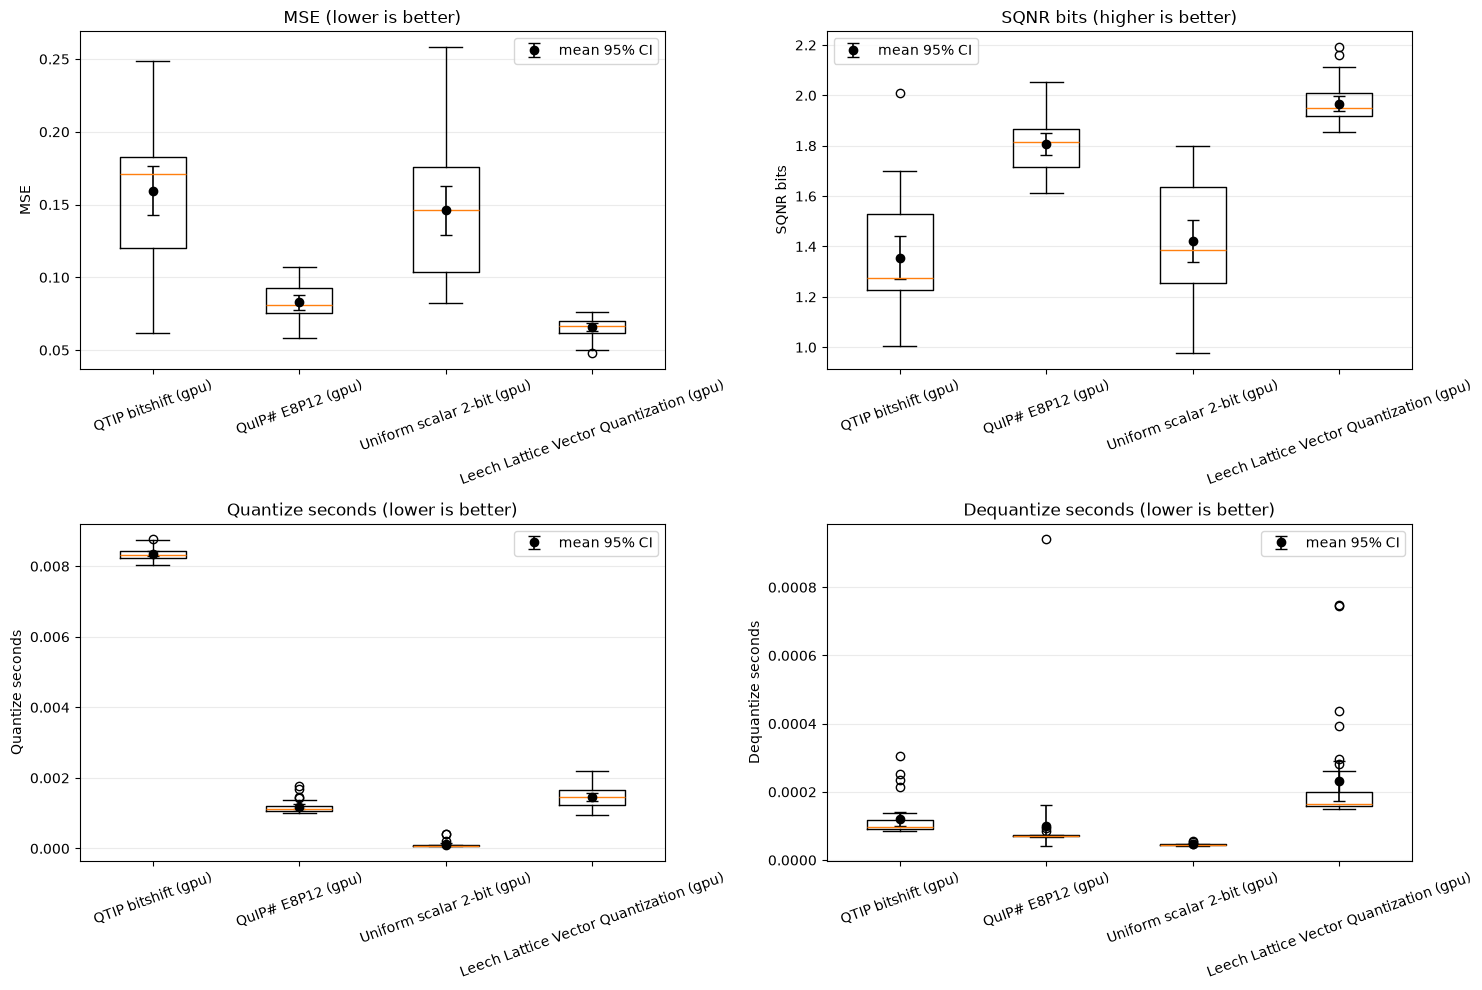

Pilot metric distributions with fitted normal references


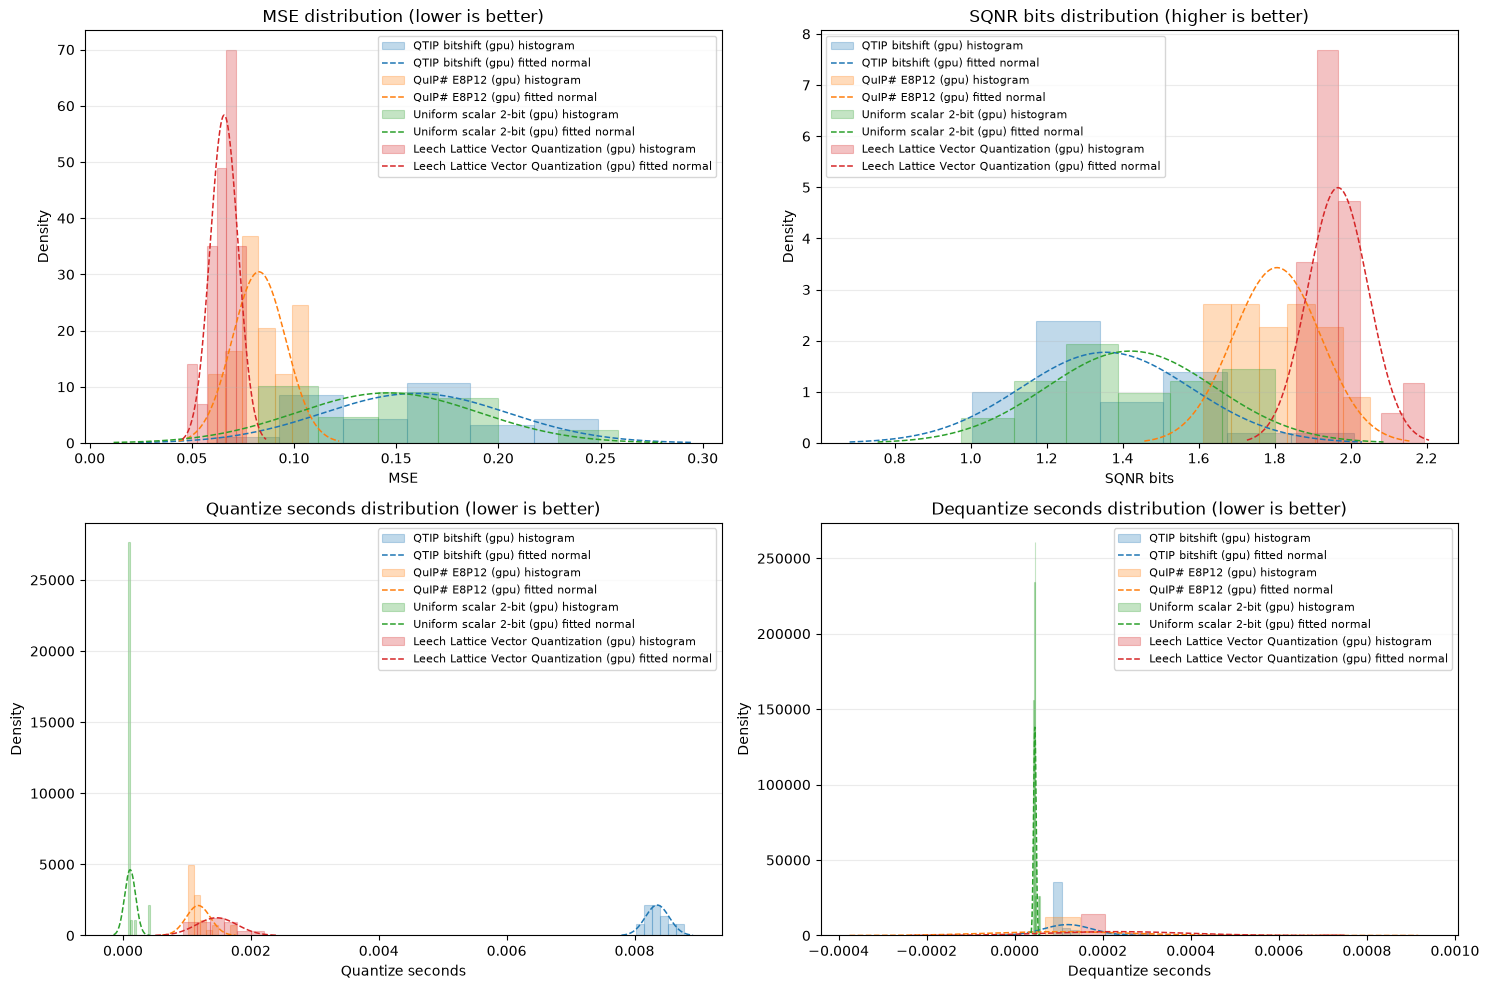

In [91]:
seed_everything(SEED)
pilot_rng = make_rng(1)
PILOT_N = max(PILOT_QUALITY_N, PILOT_TIMING_REPEATS)
pilot_batch_n = PILOT_N
pilot_x = make_input_blocks(pilot_batch_n, pilot_rng, offset_blocks=0)
quantizer_items, qtip_status = make_quantizer_items()
print(f"Using pilot runs = {PILOT_N}")
print(f"Data source: {DATA_SOURCE}")
if DATA_SOURCE == "llm_weight_blocks":
    print(f"LLM tensors: {LLM_REPO_ID}:{LLM_TENSOR_NAME_PATTERN} ({LLM_WEIGHT_NORMALIZATION}, sample_seed={LLM_SAMPLE_SEED})")
print(f"Optional quantizer status: {qtip_status}")
print("Algorithms:")
for item in quantizer_items:
    print(f"- {item['method']} | rate={item['rate']:.3f} bpd")

pilot_csv, pilot_quality_sqnr, pilot_quantize_seconds, pilot_dequantize_seconds, pilot_reports = run_combined_experiment(
    quantizer_items,
    pilot_x,
    phase="pilot",
    n_runs=PILOT_N,
    warmup=TIMING_WARMUP_REPEATS,
    order_seed=SEED + 10,
)

pilot_results = reports_table(pilot_reports)
pilot_data_statistics = final_data_statistics_from_csv(pilot_csv, confidence=0.95)

pilot_quality_sqnr_from_csv = load_metric_samples_from_experiment_csv(pilot_csv, "sqnr_bits")
pilot_quantize_seconds_from_csv = load_metric_samples_from_experiment_csv(pilot_csv, "quantize_seconds")
pilot_dequantize_seconds_from_csv = load_metric_samples_from_experiment_csv(pilot_csv, "dequantize_seconds")
pilot_metric_samples = {
    "sqnr_bits": {
        "samples": pilot_quality_sqnr_from_csv,
        "sample_unit": "vectors",
        "higher_is_better": True,
    },
    "quantize_seconds": {
        "samples": pilot_quantize_seconds_from_csv,
        "sample_unit": "timing_repeats",
        "higher_is_better": False,
    },
    "dequantize_seconds": {
        "samples": pilot_dequantize_seconds_from_csv,
        "sample_unit": "timing_repeats",
        "higher_is_better": False,
    },
}
pilot_assumption_check_table = anova_assumption_checks(pilot_metric_samples)
pilot_normality_check_table = pilot_assumption_check_table[
    pilot_assumption_check_table["assumption"].eq("normality_of_rm_anova_residuals")
].reset_index(drop=True)

print(f"Pilot CSV: {pilot_csv}")
print("Pilot summary")
display(pilot_results)
print("Pilot data statistics")
display(pilot_data_statistics)
print("Pilot normality checks")
display(pilot_normality_check_table)
print("Pilot metric boxplots with mean 95% confidence intervals")
pilot_metric_boxplot_figure = plot_metric_boxplots_with_ci(pilot_csv, pilot_data_statistics)
plt.show()
print("Pilot metric distributions with fitted normal references")
pilot_metric_distribution_figure = plot_metric_distributions_with_normal_reference(pilot_csv)
plt.show()


## Parametric ANOVA sample size calculation

This block estimates the within-algorithm variance from the pilot CSV, evaluates the `two_levels_symmetric` and `one_vs_rest` mean-difference scenarios, and chooses the largest sample size across SQNR, quantize time, and dequantize time.


## Sample-size planning setup


In [92]:
# Sample-size planning reads the pilot CSV back from disk after the pilot statistics, diagnostics, and plots.
pilot_sd_n = pilot_sample_size_for_sd(confidence=0.95, relative_error=0.25)
method_names = [item["method"] for item in quantizer_items]
planned_metrics = ["sqnr_bits", "quantize_seconds", "dequantize_seconds"]
planned_comparisons = planned_comparisons_table(method_names, planned_metrics, alpha_family=ALPHA)
alpha_pair, total_pairwise_tests = pairwise_alpha_for_scope(len(quantizer_items), ALPHA)

sample_size_procedure = pd.DataFrame([
    {
        "step": 1,
        "procedure": "Choose ANOVA effect scenarios",
        "notebook_value": ", ".join(ANOVA_EFFECT_SCENARIOS),
    },
    {
        "step": 2,
        "procedure": "Estimate within variance from the pilot data",
        "notebook_value": "one-way ANOVA within-group residual variance for each metric",
    },
    {
        "step": 3,
        "procedure": "Calculate global ANOVA F-test power",
        "notebook_value": "noncentral F distribution with df1=a-1 and df2=a(n-1)",
    },
    {
        "step": 4,
        "procedure": "Find smallest n per algorithm reaching target power",
        "notebook_value": f"alpha={ALPHA}, power={POWER}",
    },
    {
        "step": 5,
        "procedure": "Use the largest required sample size",
        "notebook_value": "one shared final n across metrics and ANOVA scenarios",
    },
])


## ANOVA sample-size calculation


In [93]:
quality_anova_sample_size_table = anova_sample_size_table_from_samples(
    pilot_quality_sqnr_from_csv,
    alpha=ALPHA,
    power=POWER,
    delta=MIN_INTERESTING_SQNR_BITS_DIFF,
    metric="sqnr_bits",
    sample_unit="vectors",
)
quantize_time_anova_sample_size_table = anova_sample_size_table_from_samples(
    pilot_quantize_seconds_from_csv,
    alpha=ALPHA,
    power=POWER,
    delta=MIN_INTERESTING_QUANTIZE_SECONDS,
    metric="quantize_seconds",
    sample_unit="timing_repeats",
)
dequantize_time_anova_sample_size_table = anova_sample_size_table_from_samples(
    pilot_dequantize_seconds_from_csv,
    alpha=ALPHA,
    power=POWER,
    delta=MIN_INTERESTING_DEQUANTIZE_SECONDS,
    metric="dequantize_seconds",
    sample_unit="timing_repeats",
)

anova_sample_size_table = pd.concat(
    [
        quality_anova_sample_size_table,
        quantize_time_anova_sample_size_table,
        dequantize_time_anova_sample_size_table,
    ],
    ignore_index=True,
)

REQUIRED_QUALITY_N = required_anova_n_from_table(quality_anova_sample_size_table)
REQUIRED_QUANTIZE_REPEATS = required_anova_n_from_table(quantize_time_anova_sample_size_table)
REQUIRED_DEQUANTIZE_REPEATS = required_anova_n_from_table(dequantize_time_anova_sample_size_table)
EXPERIMENT_N = int(max(REQUIRED_QUALITY_N, REQUIRED_QUANTIZE_REPEATS, REQUIRED_DEQUANTIZE_REPEATS))
TIMING_REPEATS = EXPERIMENT_N

quality_anova_sample_size_table = add_anova_planned_power(quality_anova_sample_size_table, EXPERIMENT_N)
quantize_time_anova_sample_size_table = add_anova_planned_power(quantize_time_anova_sample_size_table, TIMING_REPEATS)
dequantize_time_anova_sample_size_table = add_anova_planned_power(dequantize_time_anova_sample_size_table, TIMING_REPEATS)
anova_sample_size_table = pd.concat(
    [
        quality_anova_sample_size_table,
        quantize_time_anova_sample_size_table,
        dequantize_time_anova_sample_size_table,
    ],
    ignore_index=True,
)


## Sample-size summary table


In [94]:
sample_size_summary = pd.DataFrame([
    {
        "metric": "sqnr_bits",
        "sample_unit": "vectors",
        "pilot_samples_per_algorithm": PILOT_N,
        "required_samples_per_algorithm": REQUIRED_QUALITY_N,
        "planned_samples_per_algorithm": EXPERIMENT_N,
        "minimum_interesting_difference": MIN_INTERESTING_SQNR_BITS_DIFF,
        "family_alpha": ALPHA,
        "power": POWER,
        "calculation": "anova_global_f_test",
    },
    {
        "metric": "quantize_seconds",
        "sample_unit": "timing_repeats",
        "pilot_samples_per_algorithm": PILOT_N,
        "required_samples_per_algorithm": REQUIRED_QUANTIZE_REPEATS,
        "planned_samples_per_algorithm": TIMING_REPEATS,
        "minimum_interesting_difference": MIN_INTERESTING_QUANTIZE_SECONDS,
        "family_alpha": ALPHA,
        "power": POWER,
        "calculation": "anova_global_f_test",
    },
    {
        "metric": "dequantize_seconds",
        "sample_unit": "timing_repeats",
        "pilot_samples_per_algorithm": PILOT_N,
        "required_samples_per_algorithm": REQUIRED_DEQUANTIZE_REPEATS,
        "planned_samples_per_algorithm": TIMING_REPEATS,
        "minimum_interesting_difference": MIN_INTERESTING_DEQUANTIZE_SECONDS,
        "family_alpha": ALPHA,
        "power": POWER,
        "calculation": "anova_global_f_test",
    },
])


## Secondary pairwise planning check


In [95]:
# Secondary check only: post-hoc pairwise planning usually requires larger n than ANOVA-only planning.
quality_sample_size_table = add_planned_power(sample_size_table_from_samples(
    pilot_quality_sqnr_from_csv,
    alpha=ALPHA,
    power=POWER,
    delta=MIN_INTERESTING_SQNR_BITS_DIFF,
    metric="sqnr_bits",
    sample_unit="vectors",
), EXPERIMENT_N)
quantize_time_sample_size_table = add_planned_power(sample_size_table_from_samples(
    pilot_quantize_seconds_from_csv,
    alpha=ALPHA,
    power=POWER,
    delta=MIN_INTERESTING_QUANTIZE_SECONDS,
    metric="quantize_seconds",
    sample_unit="timing_repeats",
), TIMING_REPEATS)
dequantize_time_sample_size_table = add_planned_power(sample_size_table_from_samples(
    pilot_dequantize_seconds_from_csv,
    alpha=ALPHA,
    power=POWER,
    delta=MIN_INTERESTING_DEQUANTIZE_SECONDS,
    metric="dequantize_seconds",
    sample_unit="timing_repeats",
), TIMING_REPEATS)
posthoc_sample_size_table = pd.concat(
    [quality_sample_size_table, quantize_time_sample_size_table, dequantize_time_sample_size_table],
    ignore_index=True,
)


## Display sample-size results


In [96]:
print(f"Pilot-study approximation for SD estimate: n ~= {pilot_sd_n} for 95% confidence and 25% relative error")
print(f"Using PILOT_QUALITY_N = {PILOT_QUALITY_N}")
print(f"ANOVA scenarios: {', '.join(ANOVA_EFFECT_SCENARIOS)}")
print(f"Required quality vectors per algorithm: {REQUIRED_QUALITY_N}")
print(f"Required quantize timing runs per algorithm: {REQUIRED_QUANTIZE_REPEATS}")
print(f"Required dequantize timing runs per algorithm: {REQUIRED_DEQUANTIZE_REPEATS}")
print(f"Final shared experiment runs per algorithm: {EXPERIMENT_N}")
print(f"Post-hoc adjusted alpha per comparison for secondary check: {alpha_pair:.6g}")

print("Pilot-based sample-size calculation")
display(sample_size_procedure)
print("ANOVA global sample-size summary")
display(sample_size_summary)
print("ANOVA global sample-size details")
display(anova_sample_size_table)
print("Planned post-hoc comparisons and adjusted alpha, secondary check")
display(planned_comparisons)
print("Post-hoc pairwise sample-size check, not used for EXPERIMENT_N")
posthoc_sample_size_table


Pilot-study approximation for SD estimate: n ~= 123 for 95% confidence and 25% relative error
Using PILOT_QUALITY_N = 30
ANOVA scenarios: two_levels_symmetric, one_vs_rest
Required quality vectors per algorithm: 67
Required quantize timing runs per algorithm: 2
Required dequantize timing runs per algorithm: 2
Final shared experiment runs per algorithm: 67
Post-hoc adjusted alpha per comparison for secondary check: 0.00277778
Pilot-based sample-size calculation


,step,procedure,notebook_value
0,1,Choose ANOVA effect scenarios,"two_levels_symmetric, one_vs_rest"
1,2,Estimate within variance from the pilot data,one-way ANOVA within-group residual variance f...
2,3,Calculate global ANOVA F-test power,noncentral F distribution with df1=a-1 and df2...
3,4,Find smallest n per algorithm reaching target ...,"alpha=0.05, power=0.8"
4,5,Use the largest required sample size,one shared final n across metrics and ANOVA sc...


ANOVA global sample-size summary


,metric,sample_unit,pilot_samples_per_algorithm,required_samples_per_algorithm,planned_samples_per_algorithm,minimum_interesting_difference,family_alpha,power,calculation
0,sqnr_bits,vectors,30,67,67,0.10,0.05,0.8,anova_global_f_test
1,quantize_seconds,timing_repeats,30,2,67,0.10,0.05,0.8,anova_global_f_test
2,dequantize_seconds,timing_repeats,30,2,67,0.01,0.05,0.8,anova_global_f_test


ANOVA global sample-size details


,metric,sample_unit,test,scenario,n_algorithms,pilot_samples_per_algorithm,minimum_interesting_difference,family_alpha,power,pilot_within_variance,pilot_within_sd,tau_vector,sum_tau_squared,between_variance_tau,required_n_per_algorithm,achieved_power_at_required_n,planned_n_per_algorithm,achieved_power_at_planned_n,underpowered_at_planned_n
0,sqnr_bits,vectors,one_way_anova_global_f_test,two_levels_symmetric,4,30,0.10,0.05,0.8,2.993008e-02,0.173003,"[-0.05,0.05,0.0,0.0]",0.005000,0.001667,67,0.804989,67,0.804989,False
1,sqnr_bits,vectors,one_way_anova_global_f_test,one_vs_rest,4,30,0.10,0.05,0.8,2.993008e-02,0.173003,"[-0.07500000000000001,0.025,0.025,0.025]",0.007500,0.002500,45,0.804999,67,0.941956,False
2,quantize_seconds,timing_repeats,one_way_anova_global_f_test,two_levels_symmetric,4,30,0.10,0.05,0.8,4.513497e-08,0.000212,"[-0.05,0.05,0.0,0.0]",0.005000,0.001667,2,1.000000,67,1.000000,False
3,quantize_seconds,timing_repeats,one_way_anova_global_f_test,one_vs_rest,4,30,0.10,0.05,0.8,4.513497e-08,0.000212,"[-0.07500000000000001,0.025,0.025,0.025]",0.007500,0.002500,2,1.000000,67,1.000000,False
4,dequantize_seconds,timing_repeats,one_way_anova_global_f_test,two_levels_symmetric,4,30,0.01,0.05,0.8,1.317731e-08,0.000115,"[-0.005,0.005,0.0,0.0]",0.000050,0.000017,2,1.000000,67,1.000000,False
5,dequantize_seconds,timing_repeats,one_way_anova_global_f_test,one_vs_rest,4,30,0.01,0.05,0.8,1.317731e-08,0.000115,"[-0.0075,0.0025,0.0025,0.0025]",0.000075,0.000025,2,1.000000,67,1.000000,False


Planned post-hoc comparisons and adjusted alpha, secondary check


,metric,comparison,family_alpha,alpha_adjustment_method,fwer_scope,n_pairwise_algorithm_comparisons,n_metric_families_in_correction,total_planned_comparisons,adjusted_alpha
0,sqnr_bits,Leech Lattice Vector Quantization (gpu) vs Uni...,0.05,bonferroni,all_metrics,6,3,18,0.002778
1,sqnr_bits,Leech Lattice Vector Quantization (gpu) vs QTI...,0.05,bonferroni,all_metrics,6,3,18,0.002778
2,sqnr_bits,Leech Lattice Vector Quantization (gpu) vs QuI...,0.05,bonferroni,all_metrics,6,3,18,0.002778
3,sqnr_bits,Uniform scalar 2-bit (gpu) vs QTIP bitshift (gpu),0.05,bonferroni,all_metrics,6,3,18,0.002778
4,sqnr_bits,Uniform scalar 2-bit (gpu) vs QuIP# E8P12 (gpu),0.05,bonferroni,all_metrics,6,3,18,0.002778
5,sqnr_bits,QTIP bitshift (gpu) vs QuIP# E8P12 (gpu),0.05,bonferroni,all_metrics,6,3,18,0.002778
6,quantize_seconds,Leech Lattice Vector Quantization (gpu) vs Uni...,0.05,bonferroni,all_metrics,6,3,18,0.002778
7,quantize_seconds,Leech Lattice Vector Quantization (gpu) vs QTI...,0.05,bonferroni,all_metrics,6,3,18,0.002778
8,quantize_seconds,Leech Lattice Vector Quantization (gpu) vs QuI...,0.05,bonferroni,all_metrics,6,3,18,0.002778
9,quantize_seconds,Uniform scalar 2-bit (gpu) vs QTIP bitshift (gpu),0.05,bonferroni,all_metrics,6,3,18,0.002778


Post-hoc pairwise sample-size check, not used for EXPERIMENT_N


,metric,sample_unit,comparison,pilot_mean_diff,pilot_sd_diff,minimum_interesting_difference,delta,family_alpha,alpha_adjustment_method,adjusted_alpha,alpha_pair,fwer_scope,total_planned_comparisons,power,required_n,achieved_power_at_required_n,planned_n,achieved_power_at_planned_n,underpowered_at_planned_n
0,sqnr_bits,vectors,QTIP bitshift (gpu) vs QuIP# E8P12 (gpu),-0.450283,0.263081,0.10,0.10,0.05,bonferroni,0.002778,0.002778,all_metrics,18,0.8,107,0.804384,67,0.505900,True
1,sqnr_bits,vectors,QTIP bitshift (gpu) vs Leech Lattice Vector Qu...,-0.611132,0.253494,0.10,0.10,0.05,bonferroni,0.002778,0.002778,all_metrics,18,0.8,99,0.800644,67,0.551077,True
2,sqnr_bits,vectors,Uniform scalar 2-bit (gpu) vs Leech Lattice Ve...,-0.545951,0.243627,0.10,0.10,0.05,bonferroni,0.002778,0.002778,all_metrics,18,0.8,92,0.801959,67,0.600496,True
3,sqnr_bits,vectors,QuIP# E8P12 (gpu) vs Uniform scalar 2-bit (gpu),0.385103,0.243388,0.10,0.10,0.05,bonferroni,0.002778,0.002778,all_metrics,18,0.8,92,0.803004,67,0.601722,True
4,sqnr_bits,vectors,QTIP bitshift (gpu) vs Uniform scalar 2-bit (gpu),-0.065181,0.157945,0.10,0.10,0.05,bonferroni,0.002778,0.002778,all_metrics,18,0.8,42,0.812317,67,0.977953,False
5,sqnr_bits,vectors,QuIP# E8P12 (gpu) vs Leech Lattice Vector Quan...,-0.160849,0.131801,0.10,0.10,0.05,bonferroni,0.002778,0.002778,all_metrics,18,0.8,31,0.819954,67,1.000000,False
6,quantize_seconds,timing_repeats,QTIP bitshift (gpu) vs QuIP# E8P12 (gpu),0.007179,0.000247,0.10,0.10,0.05,bonferroni,0.002778,0.002778,all_metrics,18,0.8,2,0.987601,67,1.000000,False
7,quantize_seconds,timing_repeats,QTIP bitshift (gpu) vs Uniform scalar 2-bit (gpu),0.008244,0.000214,0.10,0.10,0.05,bonferroni,0.002778,0.002778,all_metrics,18,0.8,2,0.995999,67,1.000000,False
8,quantize_seconds,timing_repeats,QTIP bitshift (gpu) vs Leech Lattice Vector Qu...,0.006891,0.000358,0.10,0.10,0.05,bonferroni,0.002778,0.002778,all_metrics,18,0.8,2,0.915648,67,1.000000,False
9,quantize_seconds,timing_repeats,QuIP# E8P12 (gpu) vs Uniform scalar 2-bit (gpu),0.001065,0.000208,0.10,0.10,0.05,bonferroni,0.002778,0.002778,all_metrics,18,0.8,2,0.996972,67,1.000000,False


## Final experiment

The final run uses one shared `EXPERIMENT_N`, chosen as the largest global sample size across SQNR, quantize time, and dequantize time. Each block evaluates every algorithm once on one vector and records MSE, SQNR, quantize time, and dequantize time in the same CSV row.


In [97]:
seed_everything(SEED)
final_rng = make_rng(101)
X = make_input_blocks(EXPERIMENT_N, final_rng, offset_blocks=PILOT_N)

data_csv, quality_scores_from_csv, quantize_times_from_csv, dequantize_times_from_csv, reports = run_combined_experiment(
    quantizer_items,
    X,
    phase="final",
    n_runs=EXPERIMENT_N,
    warmup=TIMING_WARMUP_REPEATS,
    order_seed=SEED + 110,
)

# Statistical inference below intentionally reloads the saved final CSV file.
quality_scores_from_csv = load_metric_samples_from_experiment_csv(data_csv, "sqnr_bits")
quantize_times_from_csv = load_metric_samples_from_experiment_csv(data_csv, "quantize_seconds")
dequantize_times_from_csv = load_metric_samples_from_experiment_csv(data_csv, "dequantize_seconds")

final_table = reports_table(reports)
final_quality_sample_size_check = add_anova_planned_power(anova_sample_size_table_from_samples(
    quality_scores_from_csv,
    alpha=ALPHA,
    power=POWER,
    delta=MIN_INTERESTING_SQNR_BITS_DIFF,
    metric="sqnr_bits",
    sample_unit="vectors",
), EXPERIMENT_N)
final_quantize_time_sample_size_check = add_anova_planned_power(anova_sample_size_table_from_samples(
    quantize_times_from_csv,
    alpha=ALPHA,
    power=POWER,
    delta=MIN_INTERESTING_QUANTIZE_SECONDS,
    metric="quantize_seconds",
    sample_unit="timing_repeats",
), EXPERIMENT_N)
final_dequantize_time_sample_size_check = add_anova_planned_power(anova_sample_size_table_from_samples(
    dequantize_times_from_csv,
    alpha=ALPHA,
    power=POWER,
    delta=MIN_INTERESTING_DEQUANTIZE_SECONDS,
    metric="dequantize_seconds",
    sample_unit="timing_repeats",
), EXPERIMENT_N)

final_timing_summary = pd.DataFrame([
    {
        "method": name,
        "quantize_seconds_mean": float(np.mean(quantize_times_from_csv[name])),
        "quantize_seconds_std": float(np.std(quantize_times_from_csv[name], ddof=1)),
        "dequantize_seconds_mean": float(np.mean(dequantize_times_from_csv[name])),
        "dequantize_seconds_std": float(np.std(dequantize_times_from_csv[name], ddof=1)),
        "timing_repeats": EXPERIMENT_N,
        "timing_batch_n": 1,
    }
    for name in quantize_times_from_csv
])

final_data_statistics = final_data_statistics_from_csv(data_csv, confidence=0.95)

metric_samples = {
    "sqnr_bits": {
        "samples": quality_scores_from_csv,
        "sample_unit": "vectors",
        "higher_is_better": True,
    },
    "quantize_seconds": {
        "samples": quantize_times_from_csv,
        "sample_unit": "timing_repeats",
        "higher_is_better": False,
    },
    "dequantize_seconds": {
        "samples": dequantize_times_from_csv,
        "sample_unit": "timing_repeats",
        "higher_is_better": False,
    },
}

assumption_check_table = anova_assumption_checks(metric_samples)
global_test_table = global_multiple_sample_tests(metric_samples)
posthoc_table = posthoc_pairwise_table(metric_samples)

print(f"Final data CSV: {data_csv}")
print("Statistical inference loaded observations from the final CSV file.")
final_table


Final data CSV: /home/diego/Documents/master/llm-quantization-benchmarks/results/quantizer_sample_size_experiment/seed0_llm_weight_blocks/final_experiment.csv
Statistical inference loaded observations from the final CSV file.


,method,rate_bpd,side_info_bpd,effective_rate_bpd,target_delta_bpd,mse,rmse,error_std,squared_error_std,sqnr_bits,scale,seconds,quantize_seconds,dequantize_seconds,metadata
0,Leech Lattice Vector Quantization (gpu),2.0,0.0,2.0,0.0,0.068445,0.261620,NaN,0.005966,1.937313,1.0,0.001577,0.001360,0.000217,"{'side_info_bpd': 0.0, 'scale_mode': 'none', '..."
1,QuIP# E8P12 (gpu),2.0,0.0,2.0,0.0,0.085553,0.292495,NaN,0.014920,1.783790,1.0,0.001208,0.001130,0.000077,"{'side_info_bpd': 0.0, 'scale_mode': 'none', '..."
2,Uniform scalar 2-bit (gpu),2.0,0.0,2.0,0.0,0.143988,0.379457,NaN,0.055666,1.444994,1.0,0.000150,0.000098,0.000053,"{'side_info_bpd': 0.0, 'scale_mode': 'none', '..."
3,QTIP bitshift (gpu),2.0,0.0,2.0,0.0,0.152946,0.391084,NaN,0.051506,1.392786,1.0,0.008376,0.008259,0.000117,"{'side_info_bpd': 0.0, 'scale_mode': 'none', '..."


Pilot CSV: /home/diego/Documents/master/llm-quantization-benchmarks/results/quantizer_sample_size_experiment/seed0_llm_weight_blocks/pilot_experiment.csv
Final data CSV: /home/diego/Documents/master/llm-quantization-benchmarks/results/quantizer_sample_size_experiment/seed0_llm_weight_blocks/final_experiment.csv
Metric boxplots with mean 95% confidence intervals


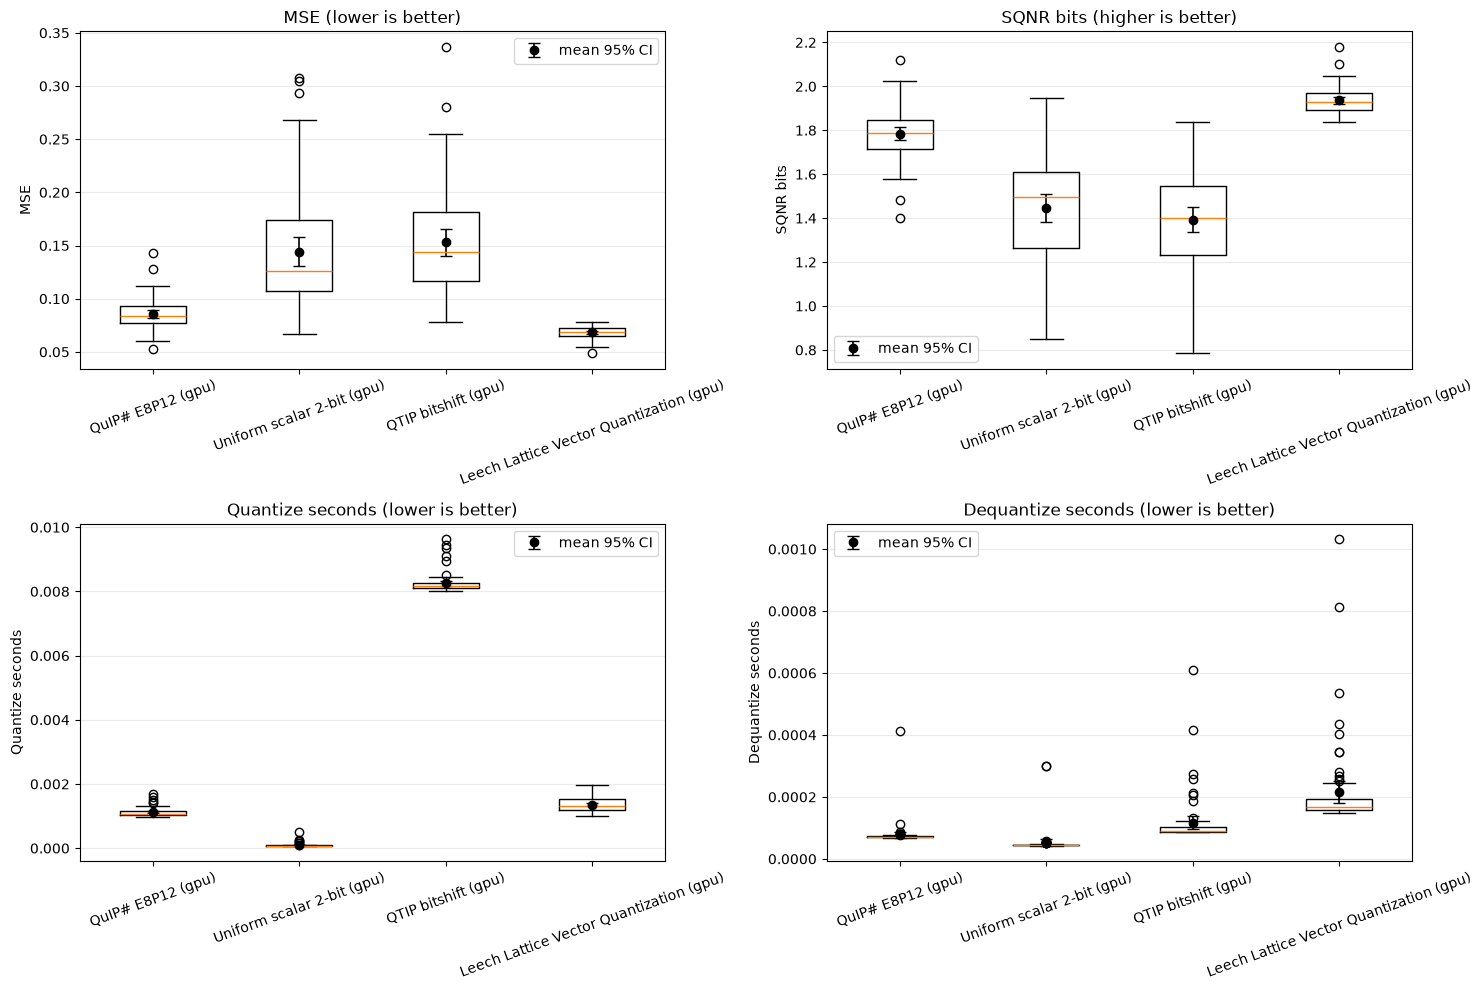

Metric distributions with fitted normal references


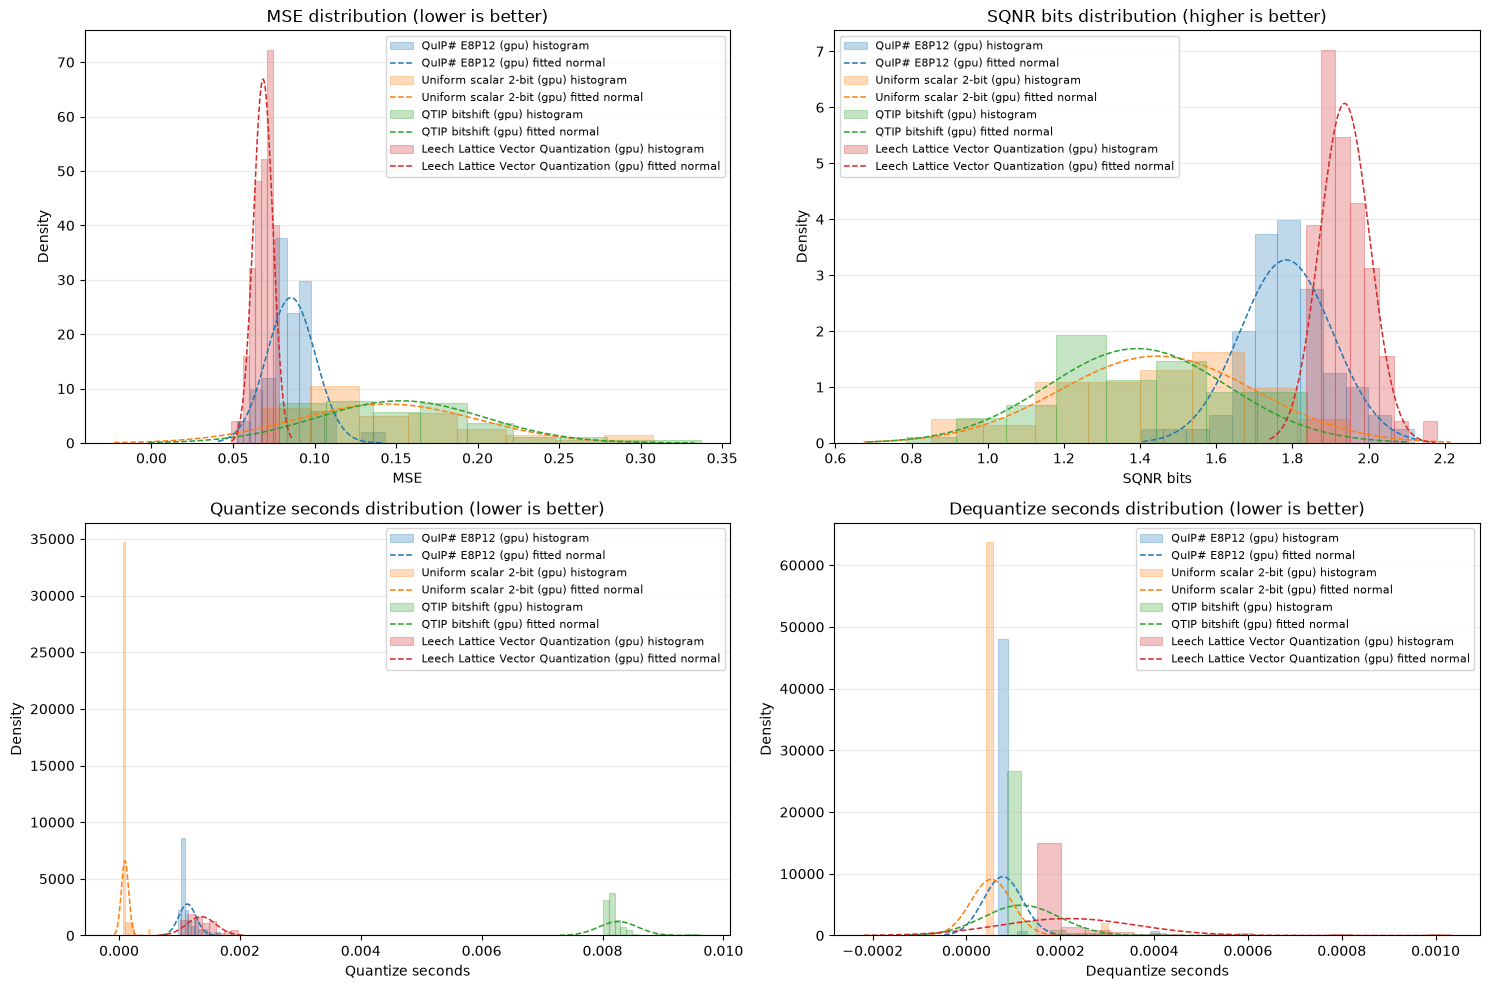

Final data statistics


,metric,method,better_direction,n,mean,std_dev,variance,std_error,coefficient_of_variation,ci_level,ci_low,ci_high,median,q25,q75,min,max
0,dequantize_seconds,Uniform scalar 2-bit (gpu),lower,67,0.000053,0.000044,1.925376e-09,0.000005,0.831045,0.95,0.000042,0.000064,0.000044,0.000044,0.000046,0.000042,0.000301
1,dequantize_seconds,QuIP# E8P12 (gpu),lower,67,0.000077,0.000042,1.752118e-09,0.000005,0.540131,0.95,0.000067,0.000088,0.000071,0.000070,0.000073,0.000067,0.000411
2,dequantize_seconds,QTIP bitshift (gpu),lower,67,0.000117,0.000081,6.598687e-09,0.000010,0.694515,0.95,0.000097,0.000137,0.000090,0.000088,0.000103,0.000086,0.000609
3,dequantize_seconds,Leech Lattice Vector Quantization (gpu),lower,67,0.000217,0.000145,2.110979e-08,0.000018,0.670724,0.95,0.000181,0.000252,0.000167,0.000158,0.000193,0.000150,0.001032
4,mse,Leech Lattice Vector Quantization (gpu),lower,67,0.068445,0.005966,3.559306e-05,0.000729,0.087165,0.95,0.066990,0.069900,0.068934,0.065031,0.072724,0.048655,0.078405
5,mse,QuIP# E8P12 (gpu),lower,67,0.085553,0.014920,2.225990e-04,0.001823,0.174391,0.95,0.081914,0.089193,0.083974,0.077287,0.092765,0.052958,0.143246
6,mse,Uniform scalar 2-bit (gpu),lower,67,0.143988,0.055666,3.098750e-03,0.006801,0.386605,0.95,0.130410,0.157566,0.125762,0.107227,0.173577,0.067143,0.307437
7,mse,QTIP bitshift (gpu),lower,67,0.152946,0.051506,2.652855e-03,0.006292,0.336758,0.95,0.140383,0.165510,0.143540,0.117088,0.181612,0.078251,0.336991
8,quantize_seconds,Uniform scalar 2-bit (gpu),lower,67,0.000098,0.000061,3.665783e-09,0.000007,0.619957,0.95,0.000083,0.000112,0.000081,0.000077,0.000089,0.000074,0.000505
9,quantize_seconds,QuIP# E8P12 (gpu),lower,67,0.001130,0.000144,2.067800e-08,0.000018,0.127248,0.95,0.001095,0.001165,0.001066,0.001046,0.001161,0.000976,0.001675


Shapiro-Wilk residual normality checks


,metric,sample_unit,assumption,test,statistic,p_value,alpha,passes_alpha,n_blocks,n_algorithms,note
0,sqnr_bits,vectors,normality_of_rm_anova_residuals,shapiro_wilk,0.996606,8.388632e-01,0.05,True,67,4,ok
1,quantize_seconds,timing_repeats,normality_of_rm_anova_residuals,shapiro_wilk,0.866713,1.739251e-14,0.05,False,67,4,ok
2,dequantize_seconds,timing_repeats,normality_of_rm_anova_residuals,shapiro_wilk,0.641496,2.322729e-23,0.05,False,67,4,ok


Repeated-measures ANOVA tests


...

,metric,sample_unit,test,scenario,n_algorithms,pilot_samples_per_algorithm,minimum_interesting_difference,family_alpha,power,pilot_within_variance,pilot_within_sd,tau_vector,sum_tau_squared,between_variance_tau,required_n_per_algorithm,achieved_power_at_required_n,planned_n_per_algorithm,achieved_power_at_planned_n,underpowered_at_planned_n
0,quantize_seconds,timing_repeats,one_way_anova_global_f_test,two_levels_symmetric,4,67,0.1,0.05,0.8,4.677013e-08,0.000216,"[-0.05,0.05,0.0,0.0]",0.0050,0.001667,2,1.0,67,1.0,False
1,quantize_seconds,timing_repeats,one_way_anova_global_f_test,one_vs_rest,4,67,0.1,0.05,0.8,4.677013e-08,0.000216,"[-0.07500000000000001,0.025,0.025,0.025]",0.0075,0.002500,2,1.0,67,1.0,False


ANOVA dequantize-time sample-size check


,metric,sample_unit,test,scenario,n_algorithms,pilot_samples_per_algorithm,minimum_interesting_difference,family_alpha,power,pilot_within_variance,pilot_within_sd,tau_vector,sum_tau_squared,between_variance_tau,required_n_per_algorithm,achieved_power_at_required_n,planned_n_per_algorithm,achieved_power_at_planned_n,underpowered_at_planned_n
0,dequantize_seconds,timing_repeats,one_way_anova_global_f_test,two_levels_symmetric,4,67,0.01,0.05,0.8,7.846494e-09,0.000089,"[-0.005,0.005,0.0,0.0]",0.000050,0.000017,2,1.0,67,1.0,False
1,dequantize_seconds,timing_repeats,one_way_anova_global_f_test,one_vs_rest,4,67,0.01,0.05,0.8,7.846494e-09,0.000089,"[-0.0075,0.0025,0.0025,0.0025]",0.000075,0.000025,2,1.0,67,1.0,False


Timing summary


,method,quantize_seconds_mean,quantize_seconds_std,dequantize_seconds_mean,dequantize_seconds_std,timing_repeats,timing_batch_n
0,QuIP# E8P12 (gpu),0.001130,0.000144,0.000077,0.000042,67,1
1,Uniform scalar 2-bit (gpu),0.000098,0.000061,0.000053,0.000044,67,1
2,QTIP bitshift (gpu),0.008259,0.000324,0.000117,0.000081,67,1
3,Leech Lattice Vector Quantization (gpu),0.001360,0.000240,0.000217,0.000145,67,1


In [98]:
print(f"Pilot CSV: {pilot_csv}")
print(f"Final data CSV: {data_csv}")
# Multiple-sample tests and corrected post-hoc comparisons from the final run.
print("Metric boxplots with mean 95% confidence intervals")
metric_boxplot_figure = plot_metric_boxplots_with_ci(data_csv, final_data_statistics)
plt.show()
print("Metric distributions with fitted normal references")
metric_distribution_figure = plot_metric_distributions_with_normal_reference(data_csv)
plt.show()
print("Final data statistics")
display(final_data_statistics)
print("Shapiro-Wilk residual normality checks")
display(assumption_check_table)
print("Repeated-measures ANOVA tests")
display(global_test_table)
print("Bonferroni-corrected post-hoc paired comparisons")
display(posthoc_table)
print("ANOVA quality sample-size check")
display(final_quality_sample_size_check)
print("ANOVA quantize-time sample-size check")
display(final_quantize_time_sample_size_check)
print("ANOVA dequantize-time sample-size check")
display(final_dequantize_time_sample_size_check)
print("Timing summary")
display(final_timing_summary)


## Normality versus sample size

This diagnostic reruns the residual normality check on increasing prefixes of the final paired blocks. It helps show whether the ANOVA residual normality check passes or fails as the available sample size grows.


Normality progression summary


,metric,sample_unit,first_passing_n,largest_passing_n,full_n,full_n_p_value,alpha,passes_at_full_n
0,sqnr_bits,vectors,5,67,67,8.388632e-01,0.05,True
1,quantize_seconds,timing_repeats,5,5,67,1.739251e-14,0.05,False
2,dequantize_seconds,timing_repeats,5,5,67,2.322729e-23,0.05,False


Normality progression by sample size


,metric,sample_unit,n_blocks,n_residuals,test,statistic,p_value,alpha,passes_alpha,note
0,sqnr_bits,vectors,5,20,shapiro_wilk,0.944245,2.880334e-01,0.05,True,ok
1,sqnr_bits,vectors,10,40,shapiro_wilk,0.979924,6.867205e-01,0.05,True,ok
2,sqnr_bits,vectors,15,60,shapiro_wilk,0.992404,9.717187e-01,0.05,True,ok
3,sqnr_bits,vectors,20,80,shapiro_wilk,0.992567,9.298331e-01,0.05,True,ok
4,sqnr_bits,vectors,25,100,shapiro_wilk,0.991487,7.829066e-01,0.05,True,ok
5,sqnr_bits,vectors,30,120,shapiro_wilk,0.992130,7.332628e-01,0.05,True,ok
6,sqnr_bits,vectors,40,160,shapiro_wilk,0.993293,6.692690e-01,0.05,True,ok
7,sqnr_bits,vectors,50,200,shapiro_wilk,0.994211,6.319950e-01,0.05,True,ok
8,sqnr_bits,vectors,60,240,shapiro_wilk,0.996551,8.795104e-01,0.05,True,ok
9,sqnr_bits,vectors,67,268,shapiro_wilk,0.996606,8.388632e-01,0.05,True,ok


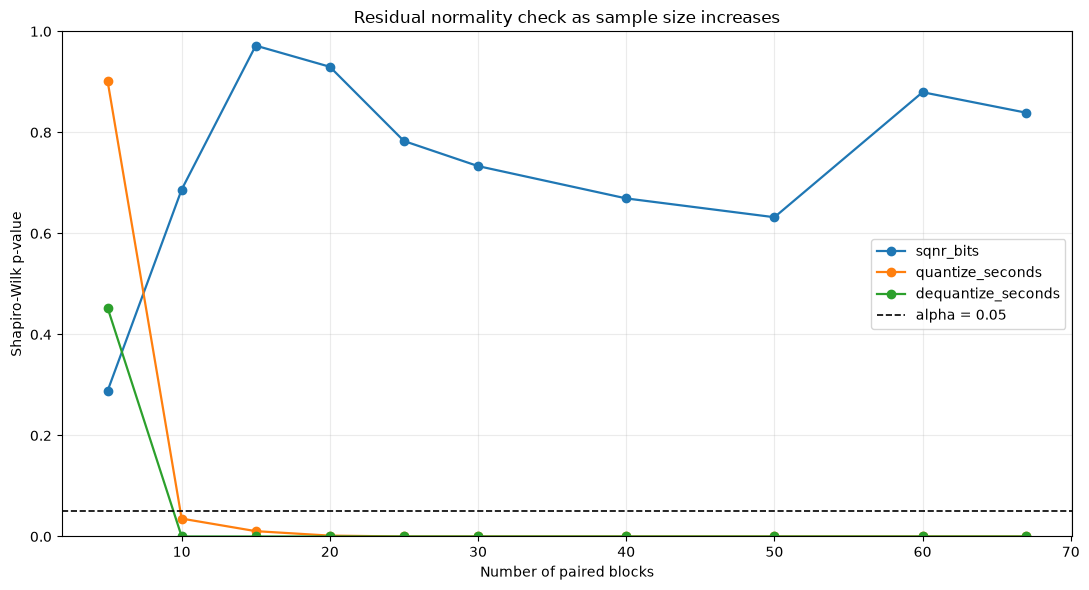

In [99]:
def normality_progression_candidate_ns(n_blocks: int) -> list[int]:
    base = [
        5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 90, 100, 125, 150, 175, 200,
        250, 300, 400, 500, 750, 1000, 1250, 1500, 1750, 2000,
    ]
    values = [n for n in base if 3 <= n <= int(n_blocks)]
    if int(n_blocks) not in values:
        values.append(int(n_blocks))
    return sorted(set(values))


def normality_progression_table(metric_samples: dict[str, dict[str, np.ndarray]], alpha: float = ALPHA) -> pd.DataFrame:
    rows = []
    for metric, spec in metric_samples.items():
        samples = spec["samples"]
        names, y = sample_matrix(samples)
        for n_blocks in normality_progression_candidate_ns(y.shape[0]):
            prefix_samples = {name: y[:n_blocks, idx] for idx, name in enumerate(names)}
            residuals = repeated_measures_residuals(prefix_samples)
            statistic, p_value, note = safe_shapiro(residuals)
            rows.append({
                "metric": metric,
                "sample_unit": spec["sample_unit"],
                "n_blocks": int(n_blocks),
                "n_residuals": int(residuals.size),
                "test": "shapiro_wilk",
                "statistic": statistic,
                "p_value": p_value,
                "alpha": float(alpha),
                "passes_alpha": bool(p_value >= alpha) if math.isfinite(p_value) else None,
                "note": note,
            })
    return pd.DataFrame(rows)


def normality_progression_summary(progress_table: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for metric, group in progress_table.groupby("metric", sort=False):
        group = group.sort_values("n_blocks")
        passing = group[group["passes_alpha"].eq(True)]
        full_row = group.iloc[-1]
        rows.append({
            "metric": metric,
            "sample_unit": full_row["sample_unit"],
            "first_passing_n": int(passing.iloc[0]["n_blocks"]) if not passing.empty else float("nan"),
            "largest_passing_n": int(passing.iloc[-1]["n_blocks"]) if not passing.empty else float("nan"),
            "full_n": int(full_row["n_blocks"]),
            "full_n_p_value": float(full_row["p_value"]),
            "alpha": float(full_row["alpha"]),
            "passes_at_full_n": bool(full_row["passes_alpha"]),
        })
    return pd.DataFrame(rows)


def plot_normality_progression(progress_table: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(11, 6))
    for metric, group in progress_table.groupby("metric", sort=False):
        group = group.sort_values("n_blocks")
        ax.plot(group["n_blocks"], group["p_value"], marker="o", linewidth=1.6, label=metric)
    alpha_value = float(progress_table["alpha"].iloc[0]) if len(progress_table) else ALPHA
    ax.axhline(alpha_value, color="black", linestyle="--", linewidth=1.2, label=f"alpha = {alpha_value:g}")
    ax.set_xlabel("Number of paired blocks")
    ax.set_ylabel("Shapiro-Wilk p-value")
    ax.set_title("Residual normality check as sample size increases")
    ax.set_ylim(bottom=0.0, top=1.0)
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    fig.tight_layout()
    return fig


normality_vs_n_table = normality_progression_table(metric_samples, alpha=ALPHA)
normality_vs_n_summary = normality_progression_summary(normality_vs_n_table)

print("Normality progression summary")
display(normality_vs_n_summary)
print("Normality progression by sample size")
display(normality_vs_n_table)
normality_vs_n_figure = plot_normality_progression(normality_vs_n_table)
plt.show()
